In [33]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import sys
import requests
import zipfile
import geopandas as gpd
import matplotlib.pyplot as plt

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
geo_root = repo_root.parent.parent / 'Data' / 'Geospatial'
plot_root = repo_root.parent.parent / 'Plots' / "CBOS"
lis_plot_root = repo_root.parent.parent / 'Plots' / 'LIS'

os.chdir(repo_root)
sys.path.append(str(repo_root / 'Code' / 'tools'))

# import local toolkit (try normal import first, fall back to loading from file)
try:
	import inequality_analyzers as inqA
except Exception:
	import importlib.util
	toolkit_path = repo_root / 'Code' / 'tools' / 'inequality_analyzers.py'
	if toolkit_path.exists():
		spec = importlib.util.spec_from_file_location("inequality_analyzers", str(toolkit_path))
		stk = importlib.util.module_from_spec(spec)
		spec.loader.exec_module(stk)
	else:
		raise

In [34]:
# Load the data file with deflated income_hh
data_file = data_root / 'CBOS_data_final_deflated_income.csv'
df = pd.read_csv(data_file)

/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_73976/673112059.py:3: DtypeWarning: Columns (14,15,20,21,22,38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_file)


In [35]:
df_new_regions = df[df['location_new_L'].notna()].copy()
regions = df_new_regions['location_new_L'].unique().tolist()
# We don't want these regions:
no_regions = ['Południowo-zachodni',
 'Północny',
 'Wschodni',
 'Południowy',
 'Północno-zachodni',
 'Centralny']

df_new_regions = df_new_regions[~df_new_regions['location_new_L'].isin(no_regions)].copy()
regions = df_new_regions['location_new_L'].unique().tolist()

# We remove white spaces from region names
df_new_regions['location_new_L'] = df_new_regions['location_new_L'].str.replace(' ', '')
regions = df_new_regions['location_new_L'].unique().tolist()


In [36]:
# Strip the dataframe
df['location_new_L'] = df['location_new_L'].str.replace(' ', '')
df['location_old_L'] = df['location_old_L'].str.replace(' ', '')

# Save the dataframe
df.to_csv(data_file, index=False)

In [37]:
df

,org_id,survey file,survey year,survey month,age,year_born,sex,sex_L,city_size,city_size_L,...,income_p_L,income_p_OLD_T,income_p_NEW_T,income_p_T,income_p_OLD_T_L,income_p_NEW_T_L,income_p_T_L,weight,survey_date,income_hh_deflated
0,1.0,CBOS_1_01_1990.sav,1990,1,0,1957.0,2.0,Kobieta,9.0,Miasto powyżej 500 tys. mieszkańców,...,NaN,0.0,0,0.0,NaN,NaN,NaN,1.000000,1990-01-01,38.000000
1,2.0,CBOS_1_01_1990.sav,1990,1,0,1950.0,2.0,Kobieta,9.0,Miasto powyżej 500 tys. mieszkańców,...,NaN,0.0,0,0.0,NaN,NaN,NaN,1.000000,1990-01-01,40.000000
2,3.0,CBOS_1_01_1990.sav,1990,1,0,1932.0,2.0,Kobieta,9.0,Miasto powyżej 500 tys. mieszkańców,...,NaN,0.0,0,0.0,NaN,NaN,NaN,1.000000,1990-01-01,17.000000
3,4.0,CBOS_1_01_1990.sav,1990,1,0,1946.0,1.0,Mężczyzna,9.0,Miasto powyżej 500 tys. mieszkańców,...,NaN,0.0,0,0.0,NaN,NaN,NaN,1.000000,1990-01-01,37.500000
4,5.0,CBOS_1_01_1990.sav,1990,1,0,1939.0,1.0,Mężczyzna,9.0,Miasto powyżej 500 tys. mieszkańców,...,NaN,0.0,0,0.0,NaN,NaN,NaN,1.000000,1990-01-01,43.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358520,921.0,CBOS_331_12_2017.sav,2017,12,0,1957.0,1.0,Mężczyzna,1.0,wieś,...,NaN,0.0,0,0.0,NaN,NaN,NaN,0.611965,2017-12-01,NaN
358521,922.0,CBOS_331_12_2017.sav,2017,12,0,1981.0,1.0,Mężczyzna,1.0,wieś,...,NaN,0.0,0,0.0,NaN,NaN,NaN,1.127158,2017-12-01,61.934773
358522,923.0,CBOS_331_12_2017.sav,2017,12,0,1976.0,1.0,Mężczyzna,5.0,miasto od 100 000 do 499 999,...,NaN,0.0,0,0.0,NaN,NaN,NaN,1.716070,2017-12-01,37.160864
358523,924.0,CBOS_331_12_2017.sav,2017,12,0,1971.0,2.0,Kobieta,5.0,miasto od 100 000 do 499 999,...,NaN,0.0,0,0.0,NaN,NaN,NaN,1.572886,2017-12-01,61.934773


In [38]:
regions_df = {}
for region in regions:
    df_region = df_new_regions[df_new_regions['location_new_L'] == region].copy()
    IA_region = inqA.InequalityAnalyzer(df_region, income_col='income_hh_deflated', annual_frequency=True)
    mean = IA_region.time_series.weighted_mean_total.values
    df_groups = IA_region.compute_income_groups()
    df_shares = IA_region.compute_income_shares()
    mean = pd.Series(mean, name='mean_income', index=df_groups.index)
    out = {'mean': mean, 'groups': df_groups, 'shares': df_shares}
    regions_df[str(region)] = out
    

Index(['GID_1', 'GID_0', 'COUNTRY', 'NAME_1', 'VARNAME_1', 'NL_NAME_1',
       'TYPE_1', 'ENGTYPE_1', 'CC_1', 'HASC_1', 'ISO_1', 'geometry'],
      dtype='object')
16 voivodeships (should be 16)


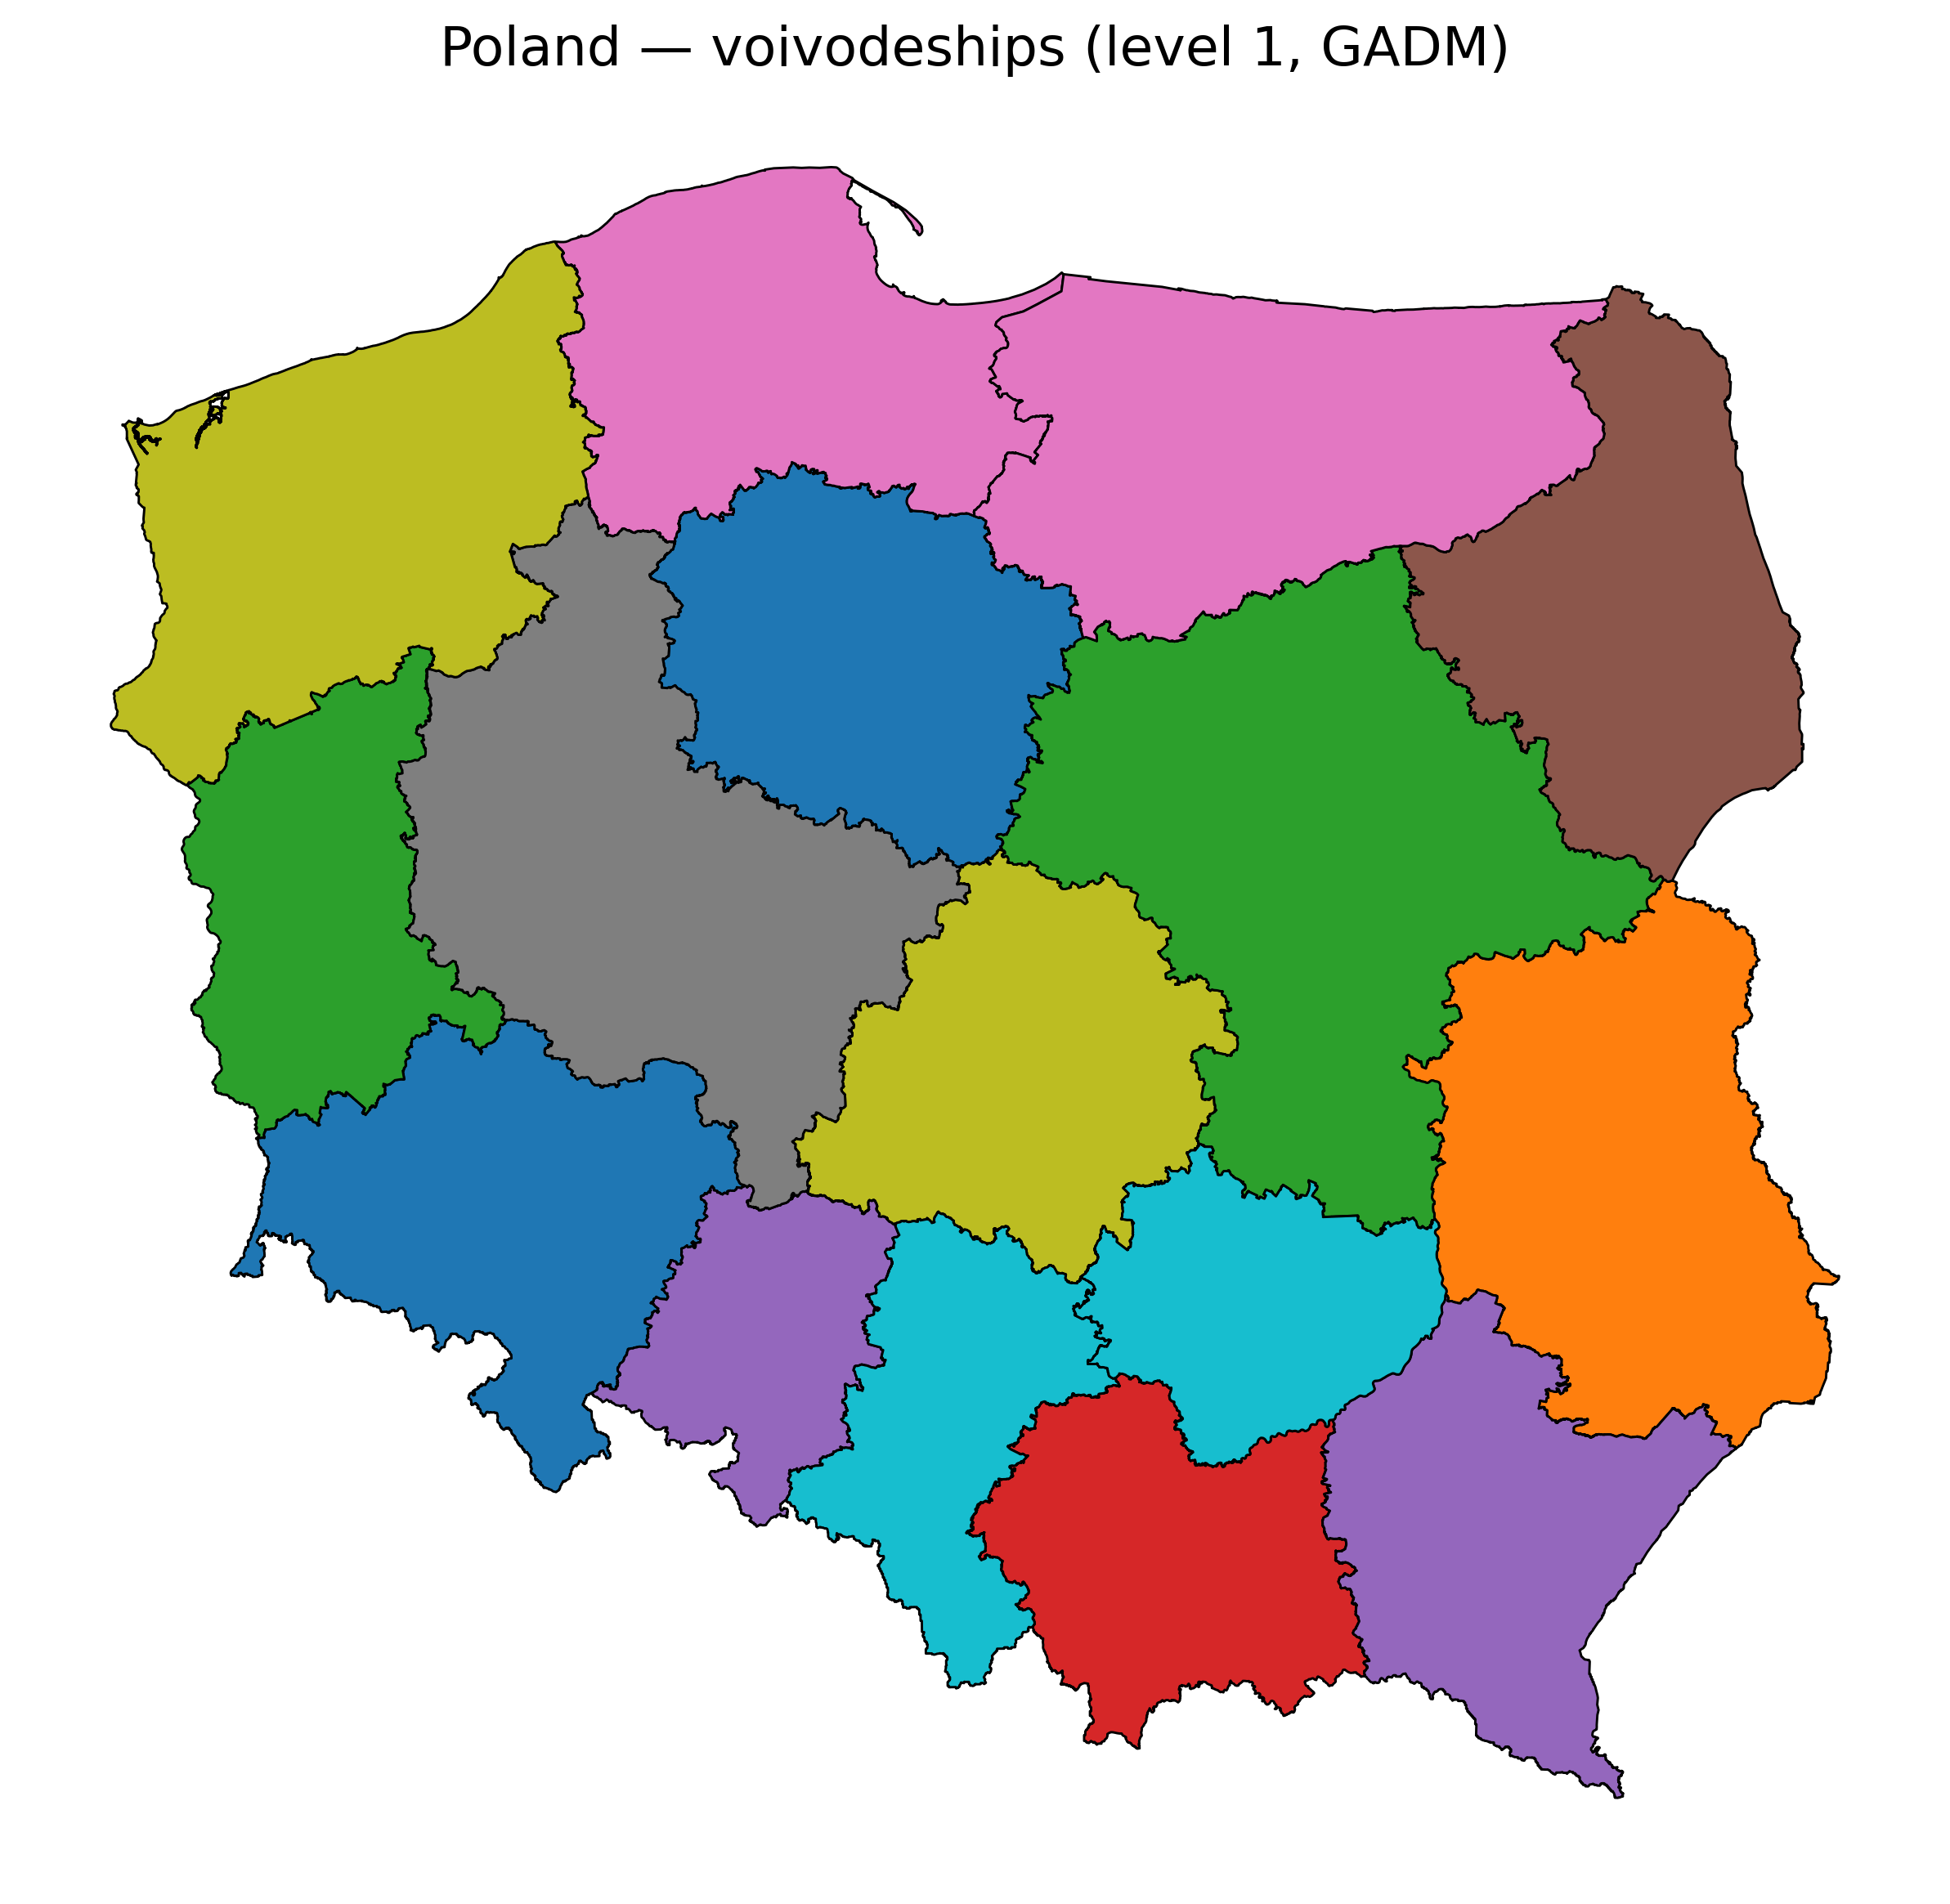

In [39]:
# 1) download GADM (example host: UC Davis geodata mirror)
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_POL_shp.zip"
zip_path = geo_root / "gadm41_POL_shp.zip"
if not os.path.exists(zip_path):
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(zip_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

# 2) unzip (optional) and read level-1 shapefile
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(geo_root / "gadm41_POL_shp")

# shapefile for admin level 1 inside the zip is typically named like: gadm41_POL_1.shp
gdf = gpd.read_file(geo_root / "gadm41_POL_shp/gadm41_POL_1.shp")  # level 1 = voivodeships

# change the names of 'Kujawsko-Pomorskie','Warmińsko-Mazurskie' to 'Kujawsko-pomorskie','Warmińsko-mazurskie'
gdf['NAME_1'] = gdf['NAME_1'].replace({'Kujawsko-Pomorskie': 'Kujawsko-pomorskie',
                                       'Warmińsko-Mazurskie': 'Warmińsko-mazurskie'})

# quick inspect
print(gdf.columns)
print(len(gdf), "voivodeships (should be 16)")

# 3) plot
ax = gdf.plot(edgecolor="black", linewidth=0.7, figsize=(10,10), column="NAME_1", legend=False)
ax.set_title("Poland — voivodeships (level 1, GADM)")
ax.axis("off")
plt.show()


In [40]:
gdf_means_1999 = gdf.copy()
for region in regions:
    means = regions_df[region]['mean']
    mean = means[means.index.year == 1999].values[0]
    gdf_means_1999.loc[gdf_means_1999['NAME_1'] == region, 'mean_income'] = mean

gdf_means_2016 = gdf.copy()
for region in regions:
    means = regions_df[region]['mean']
    mean = means[means.index.year == 2016].values[0]
    gdf_means_2016.loc[gdf_means_2016['NAME_1'] == region, 'mean_income'] = mean
    

In [41]:
import matplotlib.pyplot as plt
# Set parmeters for plots
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300
})

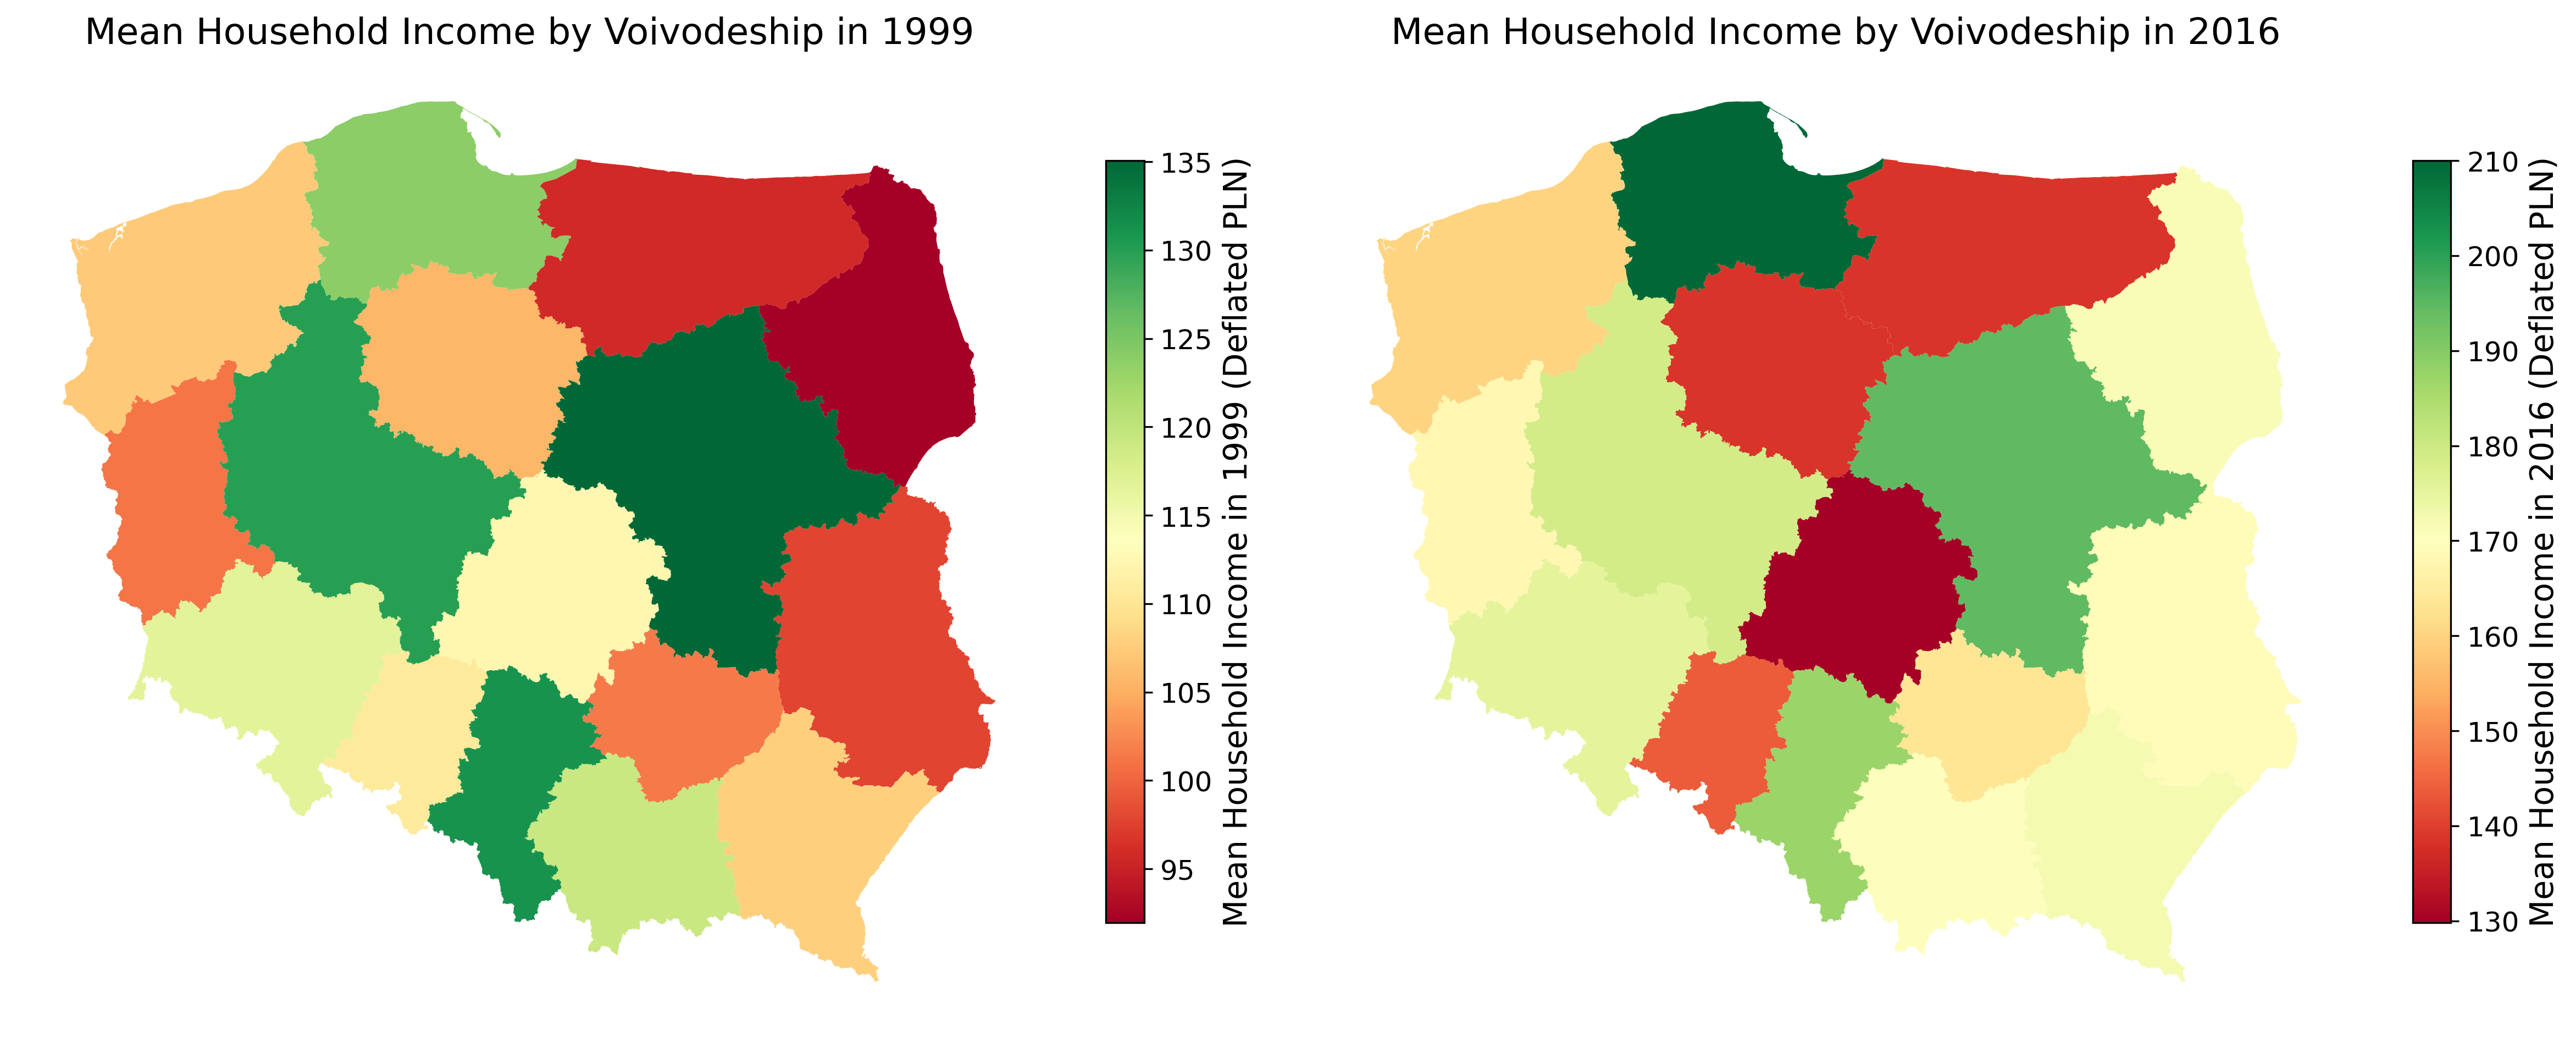

In [42]:
# two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 1990
gdf_means_1999.plot(column='mean_income', ax=ax1, cmap='RdYlGn', legend=True,
                    legend_kwds={'label': "Mean Household Income in 1999 (Deflated PLN)",
                                 'shrink': 0.6})
ax1.set_title("Mean Household Income by Voivodeship in 1999")
ax1.axis("off")
# Plot for 2016
gdf_means_2016.plot(column='mean_income', ax=ax2, cmap='RdYlGn', legend=True,
                    legend_kwds={'label': "Mean Household Income in 2016 (Deflated PLN)",
                                 'shrink': 0.6})
ax2.set_title("Mean Household Income by Voivodeship in 2016")
ax2.axis("off")
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_1_Mean_Household_Income_by_Voivodeship_1990_2016.png', dpi=300)
plt.show()

In [43]:
gdf_means_2000 = gdf.copy()
for region in regions:
    means = regions_df[region]['mean']
    mean = means[means.index.year == 2000].values[0]
    gdf_means_2000.loc[gdf_means_2000['NAME_1'] == region, 'mean_income'] = mean

gdf_means_2016 = gdf.copy()
for region in regions:
    means = regions_df[region]['mean']
    mean = means[means.index.year == 2016].values[0]
    gdf_means_2016.loc[gdf_means_2016['NAME_1'] == region, 'mean_income'] = mean
    

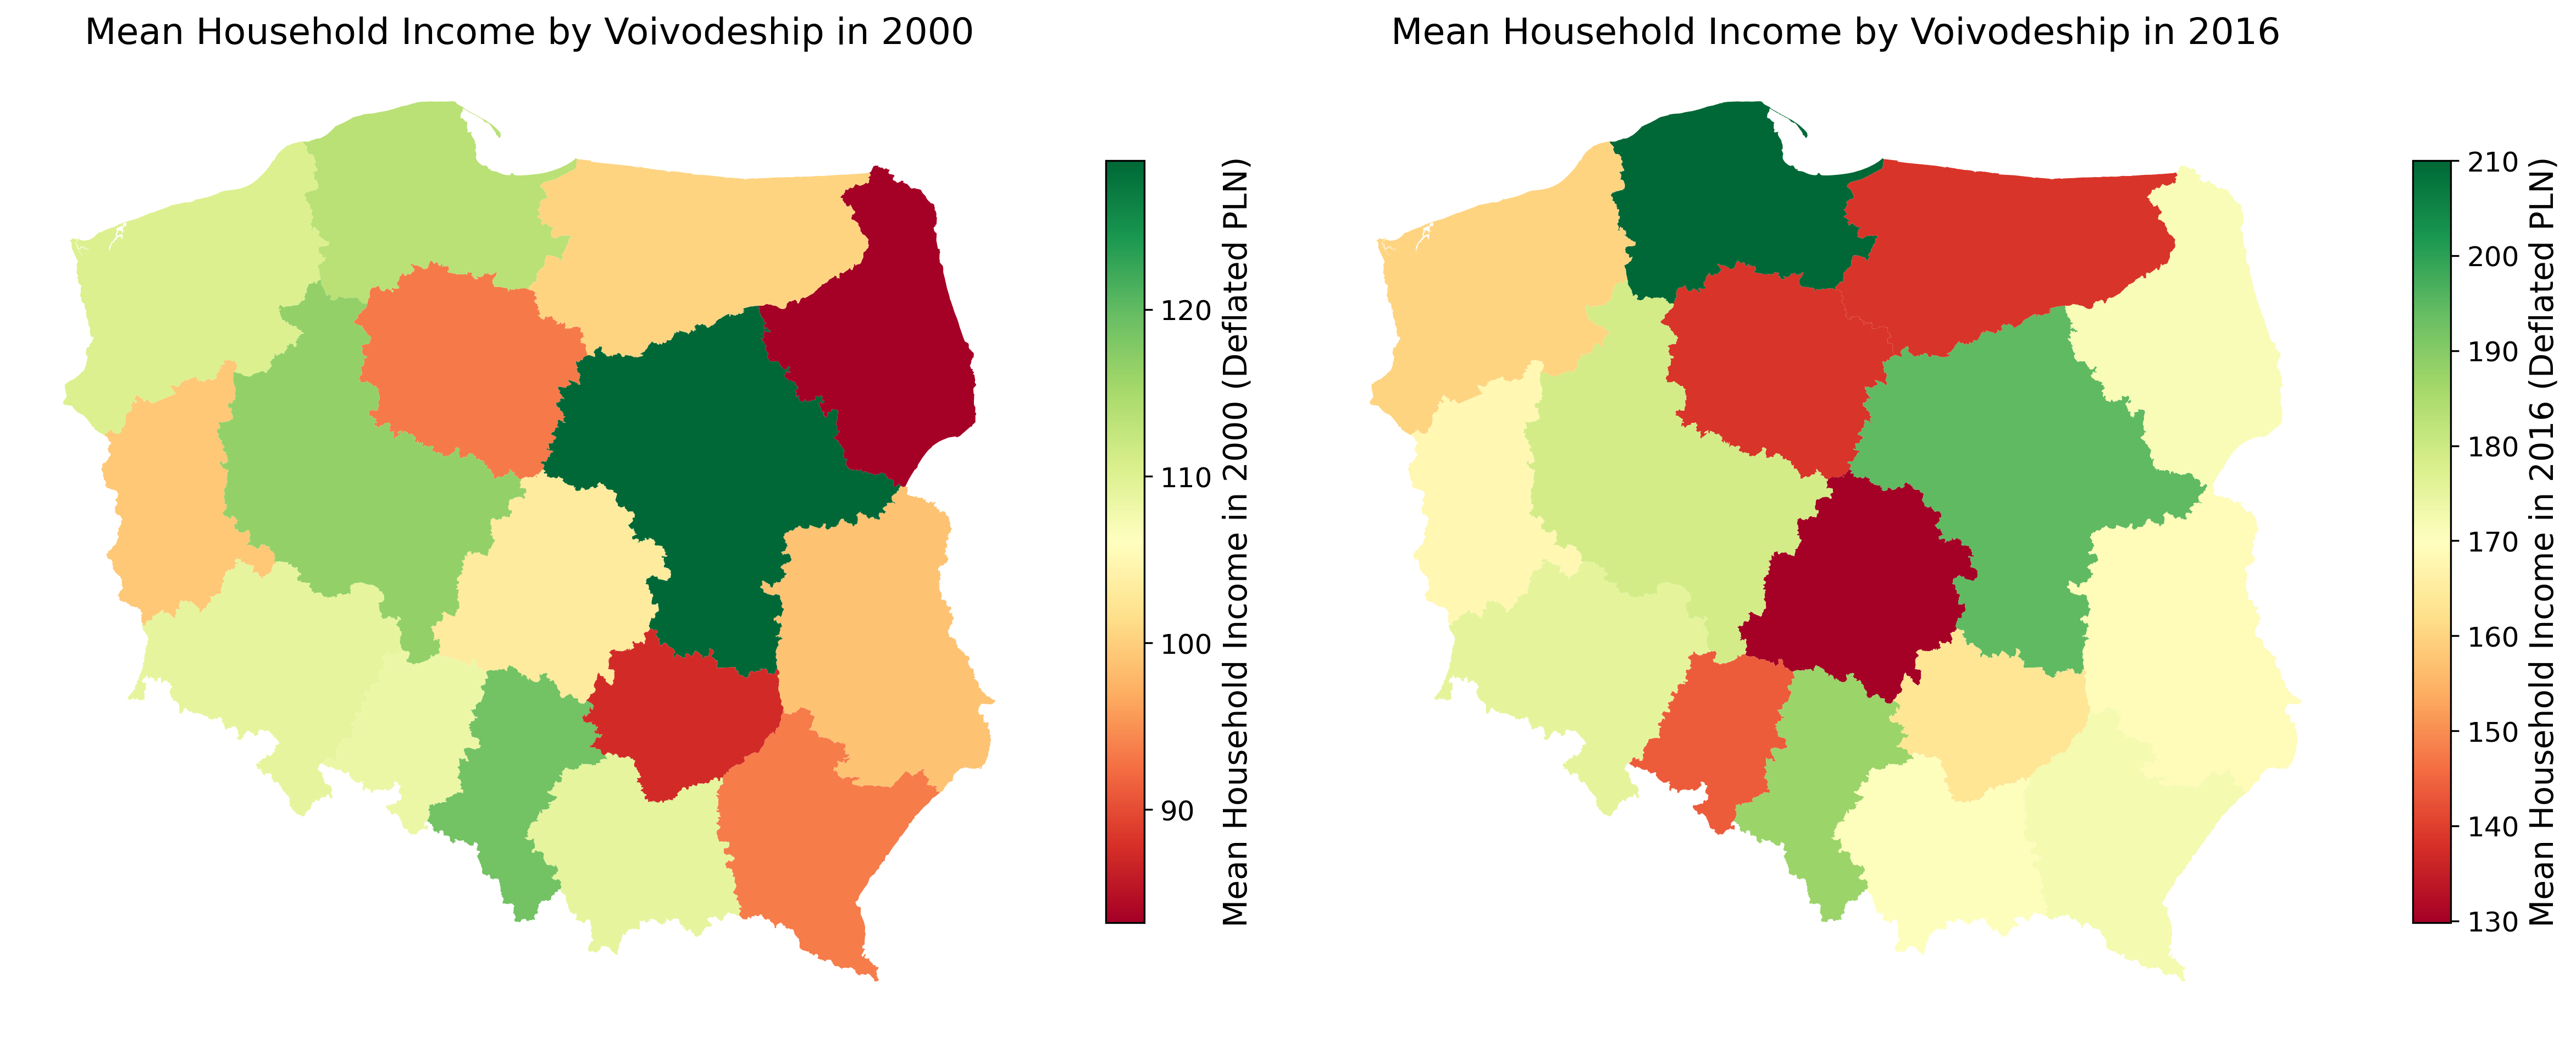

In [44]:
# two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 1990
gdf_means_2000.plot(column='mean_income', ax=ax1, cmap='RdYlGn', legend=True,
                    legend_kwds={'label': "Mean Household Income in 2000 (Deflated PLN)",
                                 'shrink': 0.6})
ax1.set_title("Mean Household Income by Voivodeship in 2000")
ax1.axis("off")
# Plot for 2016
gdf_means_2016.plot(column='mean_income', ax=ax2, cmap='RdYlGn', legend=True,
                    legend_kwds={'label': "Mean Household Income in 2016 (Deflated PLN)",
                                 'shrink': 0.6})
ax2.set_title("Mean Household Income by Voivodeship in 2016")
ax2.axis("off")
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_2_Mean_Household_Income_by_Voivodeship_2000_2016.png', dpi=300)
plt.show()

In [45]:
gdf_means_2010 = gdf.copy()
for region in regions:
    means = regions_df[region]['mean']
    mean = means[means.index.year == 2010].values[0]
    gdf_means_2010.loc[gdf_means_2010['NAME_1'] == region, 'mean_income'] = mean

gdf_means_2016 = gdf.copy()
for region in regions:
    means = regions_df[region]['mean']
    mean = means[means.index.year == 2016].values[0]
    gdf_means_2016.loc[gdf_means_2016['NAME_1'] == region, 'mean_income'] = mean
    

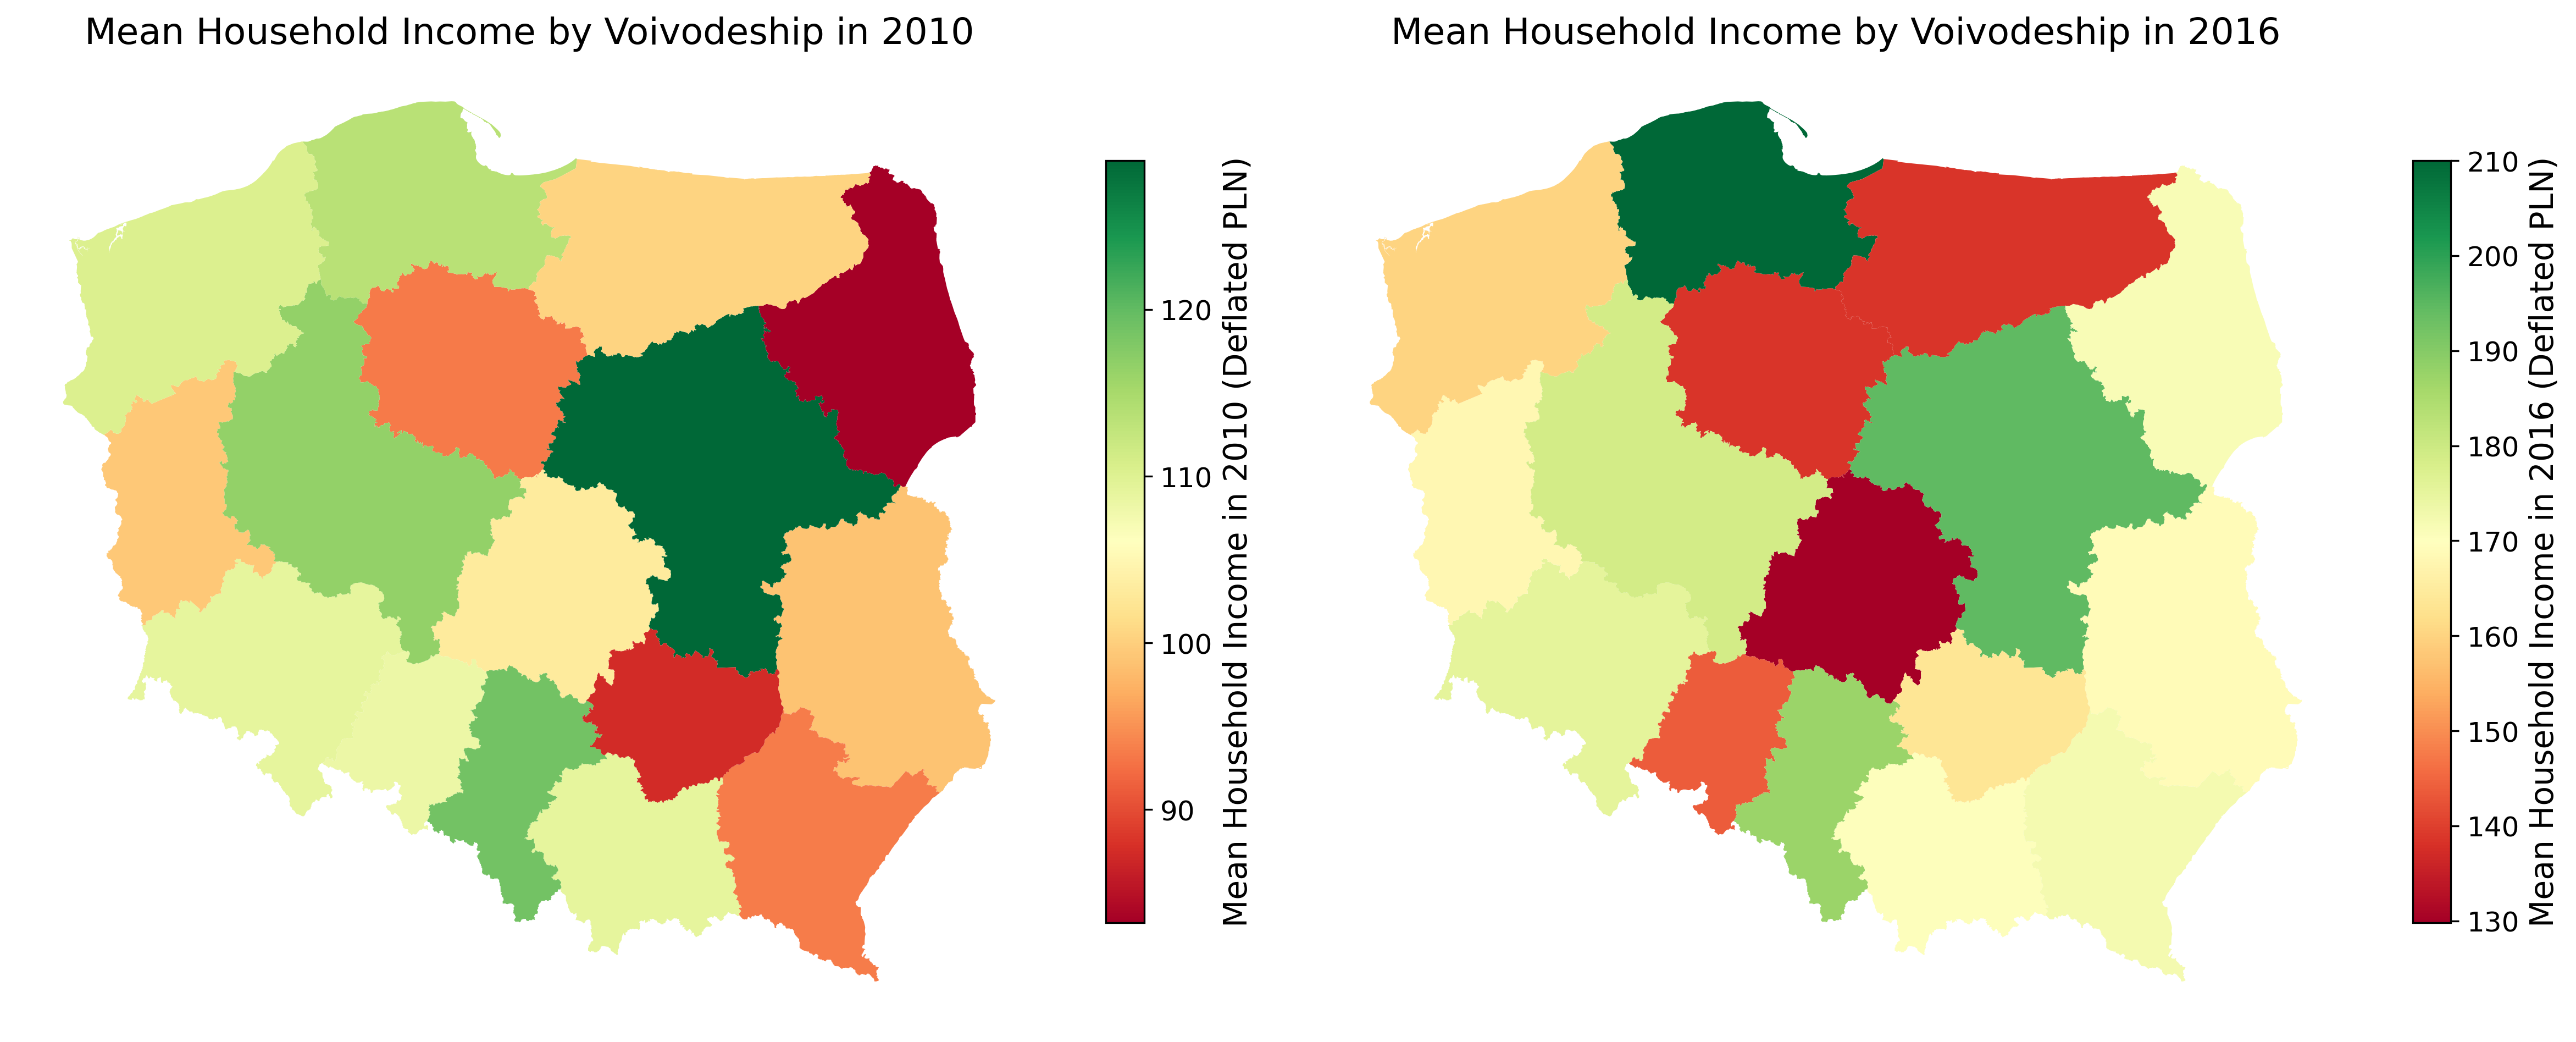

In [46]:
# two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 1990
gdf_means_2000.plot(column='mean_income', ax=ax1, cmap='RdYlGn', legend=True,
                    legend_kwds={'label': "Mean Household Income in 2010 (Deflated PLN)",
                                 'shrink': 0.6})
ax1.set_title("Mean Household Income by Voivodeship in 2010")
ax1.axis("off")
# Plot for 2016
gdf_means_2016.plot(column='mean_income', ax=ax2, cmap='RdYlGn', legend=True,
                    legend_kwds={'label': "Mean Household Income in 2016 (Deflated PLN)",
                                 'shrink': 0.6})
ax2.set_title("Mean Household Income by Voivodeship in 2016")
ax2.axis("off")
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_3_Mean_Household_Income_by_Voivodeship_2010_2016.png', dpi=300)
plt.show()

In [47]:
gdf_means_2014 = gdf.copy()
for region in regions:
    means = regions_df[region]['mean']
    mean = means[means.index.year == 2014].values[0]
    gdf_means_2014.loc[gdf_means_2014['NAME_1'] == region, 'mean_income'] = mean

gdf_means_2016 = gdf.copy()
for region in regions:
    means = regions_df[region]['mean']
    mean = means[means.index.year == 2016].values[0]
    gdf_means_2016.loc[gdf_means_2016['NAME_1'] == region, 'mean_income'] = mean
    

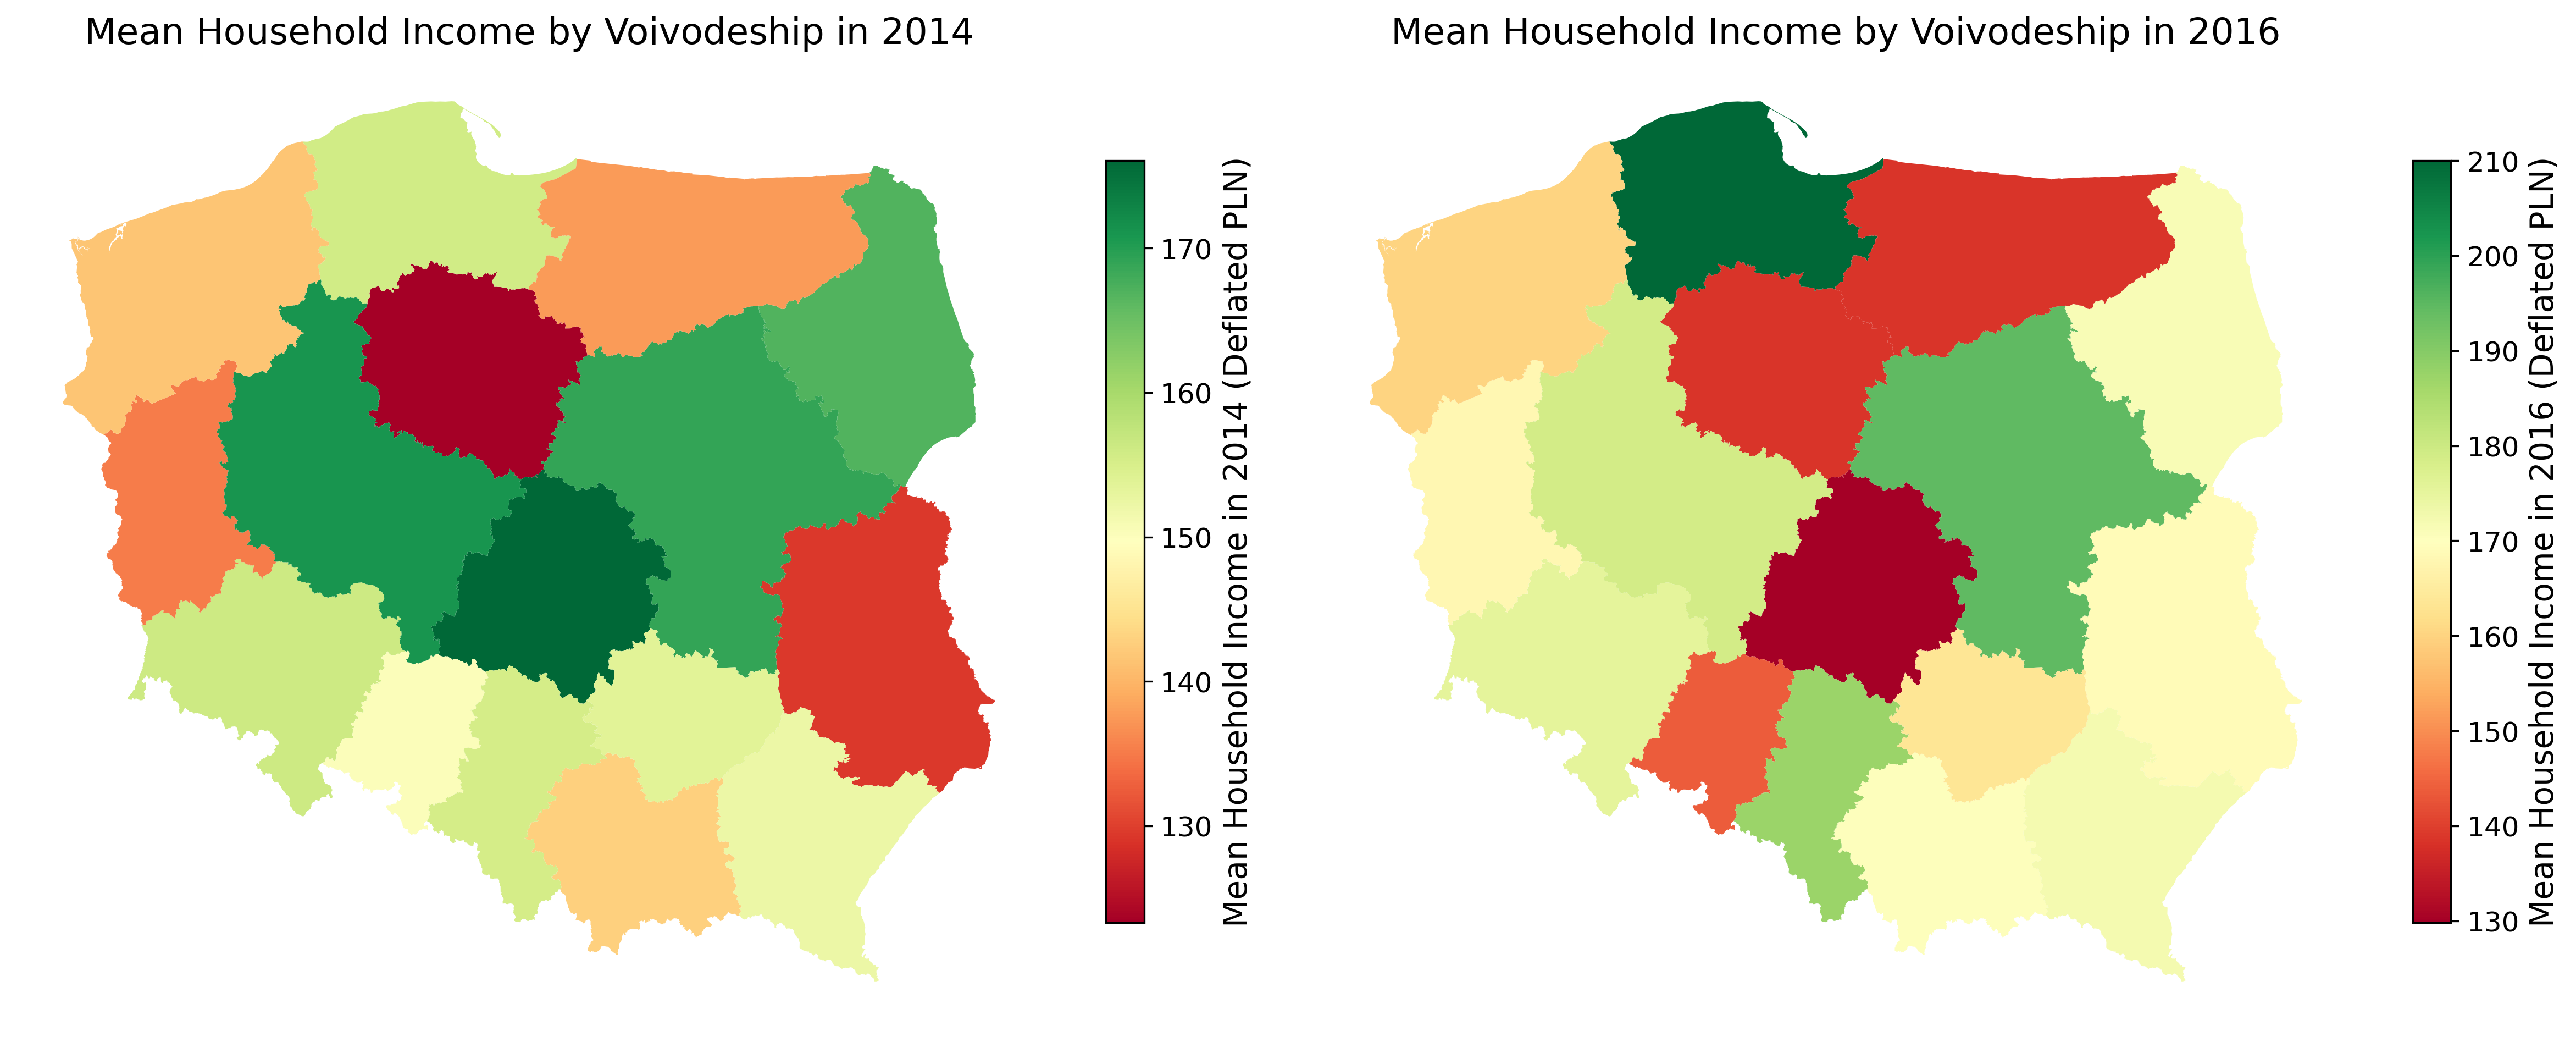

In [48]:
# two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 1990
gdf_means_2014.plot(column='mean_income', ax=ax1, cmap='RdYlGn', legend=True,
                    legend_kwds={'label': "Mean Household Income in 2014 (Deflated PLN)",
                                 'shrink': 0.6})
ax1.set_title("Mean Household Income by Voivodeship in 2014")
ax1.axis("off")
# Plot for 2016
gdf_means_2016.plot(column='mean_income', ax=ax2, cmap='RdYlGn', legend=True,
                    legend_kwds={'label': "Mean Household Income in 2016 (Deflated PLN)",
                                 'shrink': 0.6})
ax2.set_title("Mean Household Income by Voivodeship in 2016")
ax2.axis("off")
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_4_Mean_Household_Income_by_Voivodeship_2014_2016.png', dpi=300)
plt.show()

In [49]:
gdf_shares_1999 = gdf.copy()
for region in regions:
    shares = regions_df[region]['shares']
    shares = shares[shares.index.year == 1999]['top_10'].values[0]
    gdf_shares_1999.loc[gdf_shares_1999['NAME_1'] == region, 'top_10_share'] = shares

gdf_shares_2016 = gdf.copy()
for region in regions:
    shares = regions_df[region]['shares']
    shares = shares[shares.index.year == 2016]['top_10'].values[0]
    gdf_shares_2016.loc[gdf_shares_2016['NAME_1'] == region, 'top_10_share'] = shares

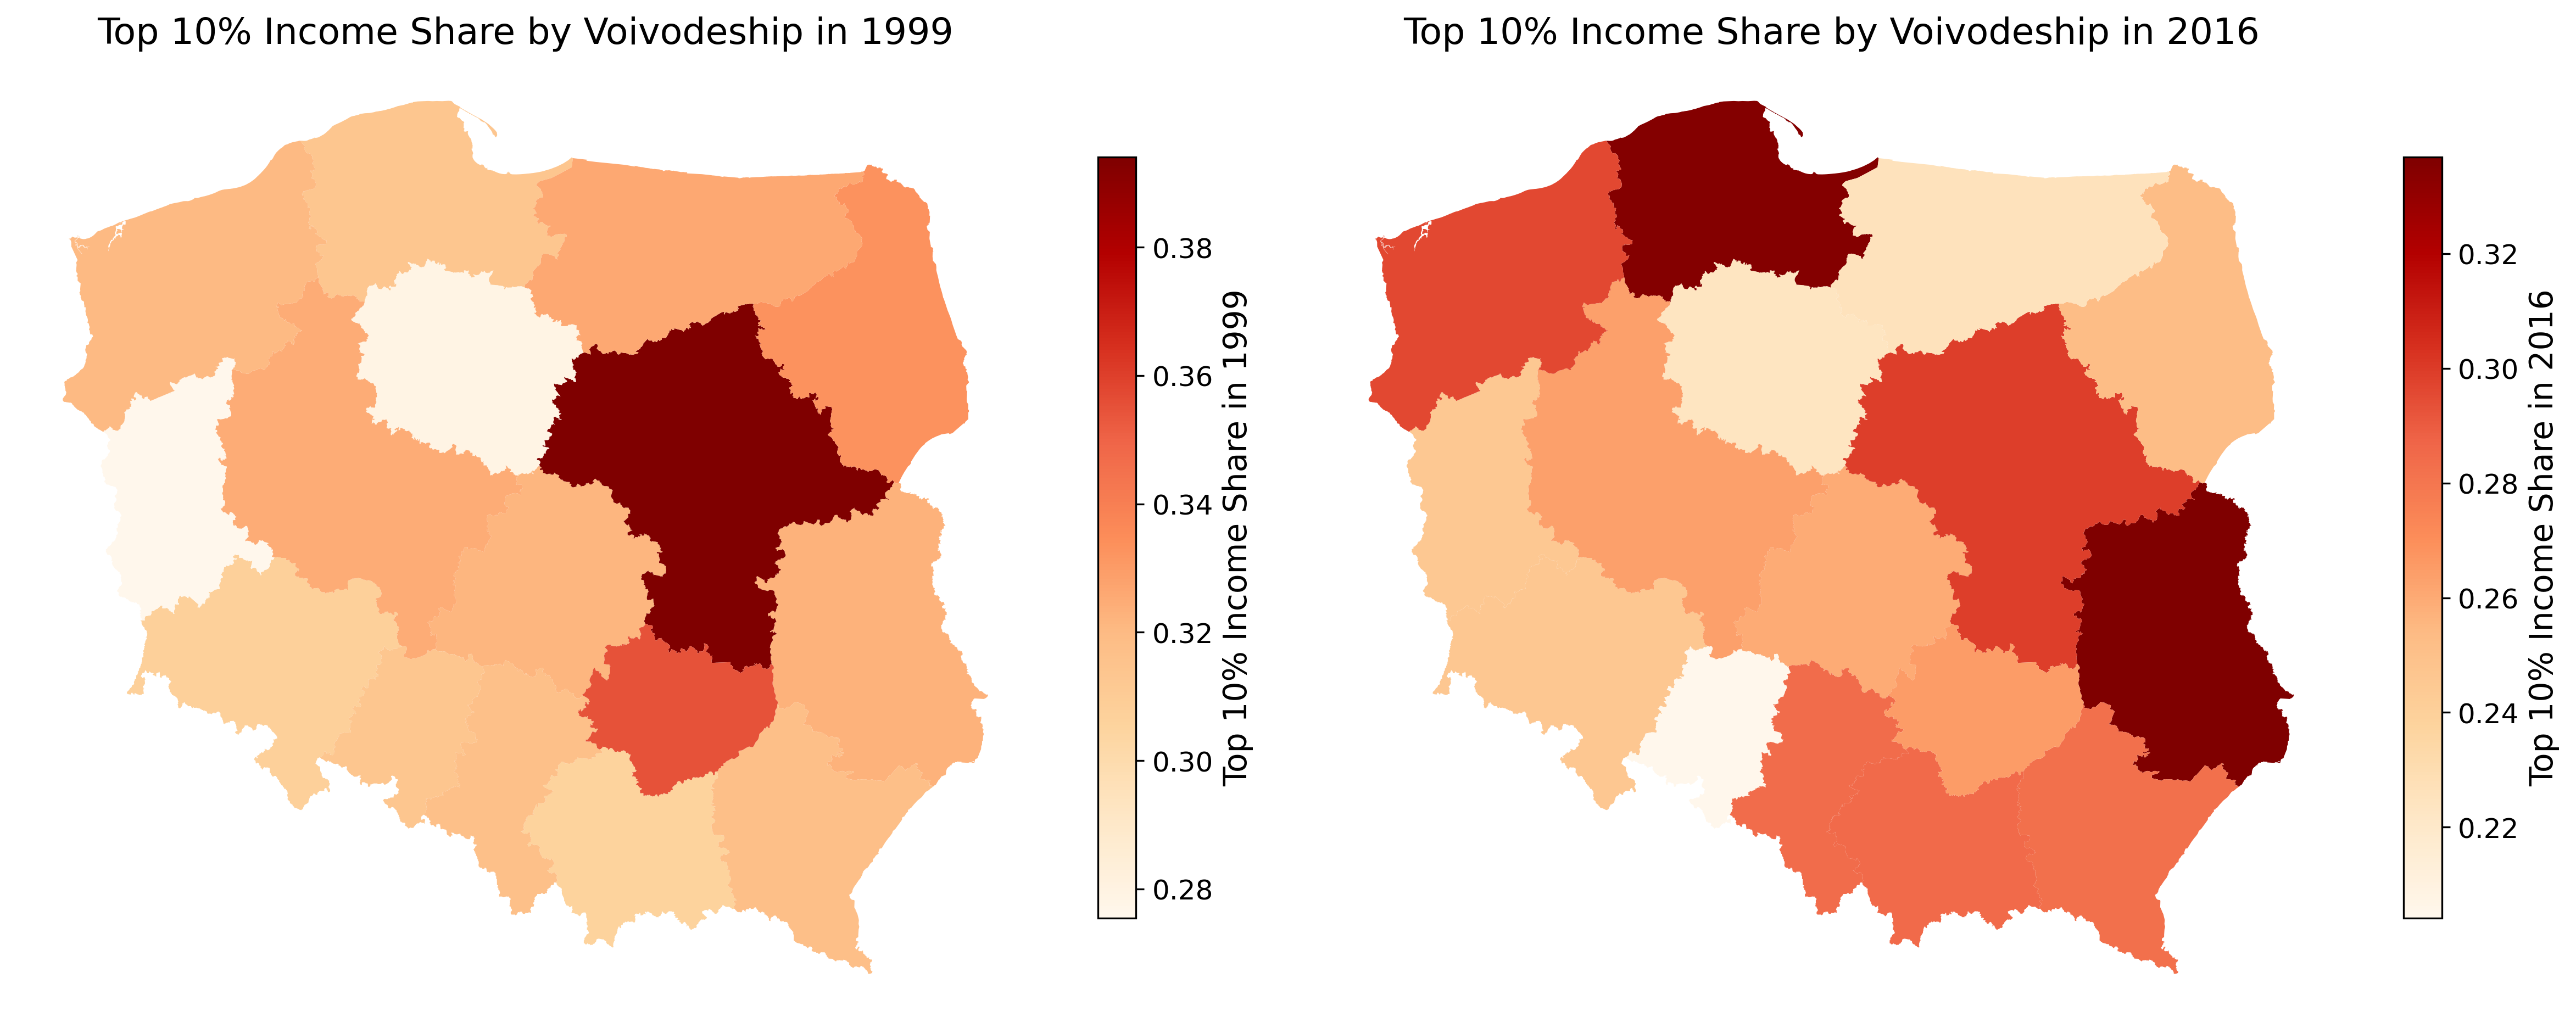

In [50]:
# Two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 1999
gdf_shares_1999.plot(column='top_10_share', ax=ax1, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share in 1999",
                                 'shrink': 0.6})
ax1.set_title("Top 10% Income Share by Voivodeship in 1999")
ax1.axis("off")
# Plot for 2016
gdf_shares_2016.plot(column='top_10_share', ax=ax2, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share in 2016",
                                 'shrink': 0.6})
ax2.set_title("Top 10% Income Share by Voivodeship in 2016")
ax2.axis("off")
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_5_Top_10_Income_Share_by_Voivodeship_1999_2016.png', dpi=300)
plt.show()

In [51]:
gdf_shares_2000 = gdf.copy()
for region in regions:
    shares = regions_df[region]['shares']
    shares = shares[shares.index.year == 2000]['top_10'].values[0]
    gdf_shares_2000.loc[gdf_shares_2000['NAME_1'] == region, 'top_10_share'] = shares

gdf_shares_2016 = gdf.copy()
for region in regions:
    shares = regions_df[region]['shares']
    shares = shares[shares.index.year == 2016]['top_10'].values[0]
    gdf_shares_2016.loc[gdf_shares_2016['NAME_1'] == region, 'top_10_share'] = shares

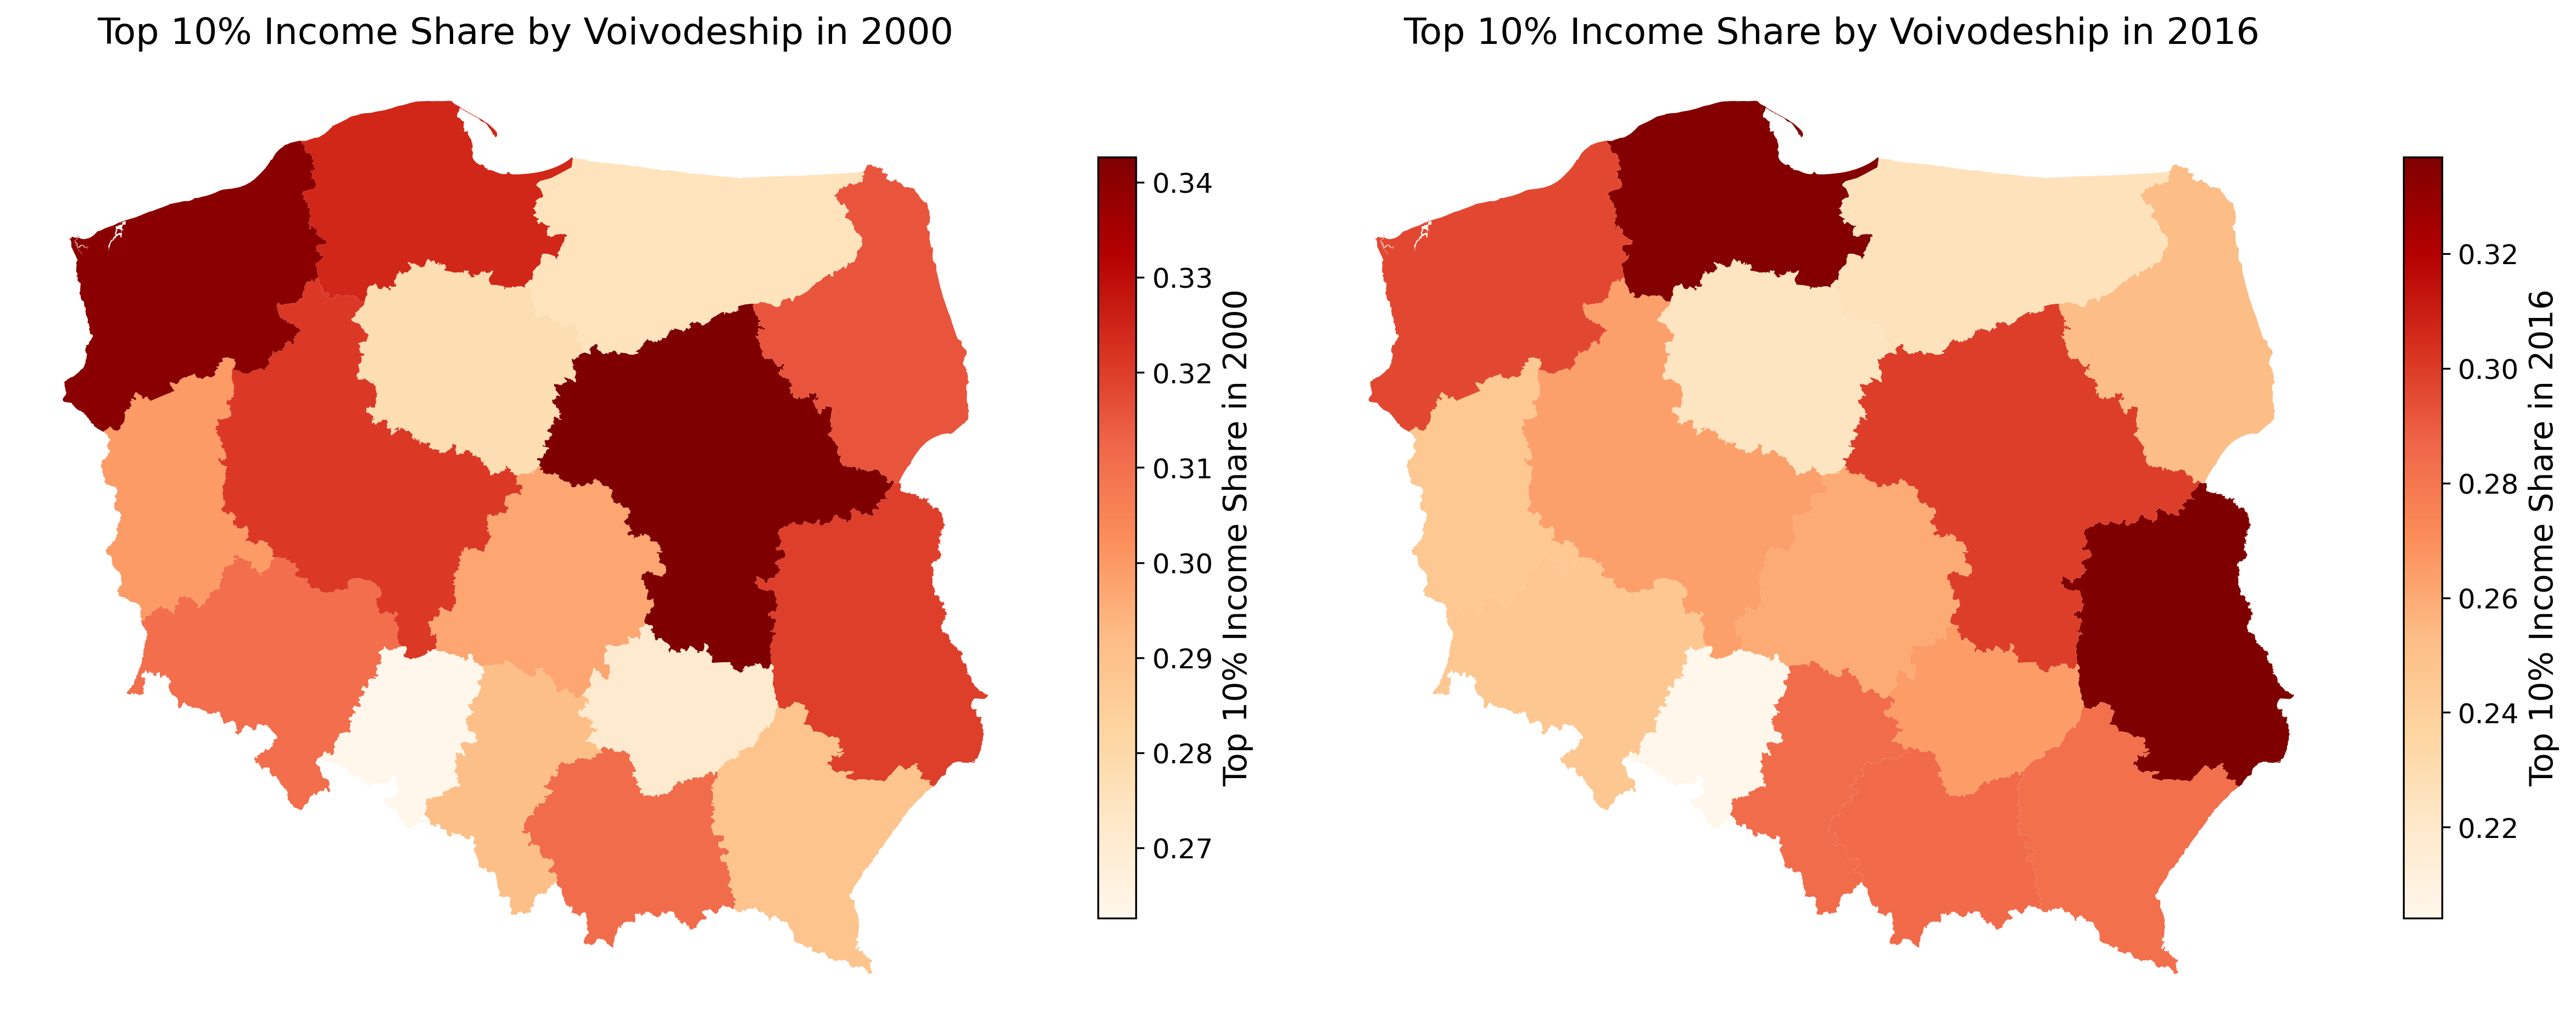

In [52]:
# two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 2000
gdf_shares_2000.plot(column='top_10_share', ax=ax1, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share in 2000",
                                 'shrink': 0.6})
ax1.set_title("Top 10% Income Share by Voivodeship in 2000")
ax1.axis("off")
# Plot for 2016
gdf_shares_2016.plot(column='top_10_share', ax=ax2, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share in 2016",
                                 'shrink': 0.6})
ax2.set_title("Top 10% Income Share by Voivodeship in 2016")
ax2.axis("off")
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_6_Top_10_Income_Share_by_Voivodeship_2000_2016.png', dpi=300)
plt.show()

In [53]:
gdf_shares_2010 = gdf.copy()
for region in regions:
    shares = regions_df[region]['shares']
    shares = shares[shares.index.year == 2010]['top_10'].values[0]
    gdf_shares_2010.loc[gdf_shares_2010['NAME_1'] == region, 'top_10_share'] = shares

gdf_shares_2016 = gdf.copy()
for region in regions:
    shares = regions_df[region]['shares']
    shares = shares[shares.index.year == 2016]['top_10'].values[0]
    gdf_shares_2016.loc[gdf_shares_2016['NAME_1'] == region, 'top_10_share'] = shares

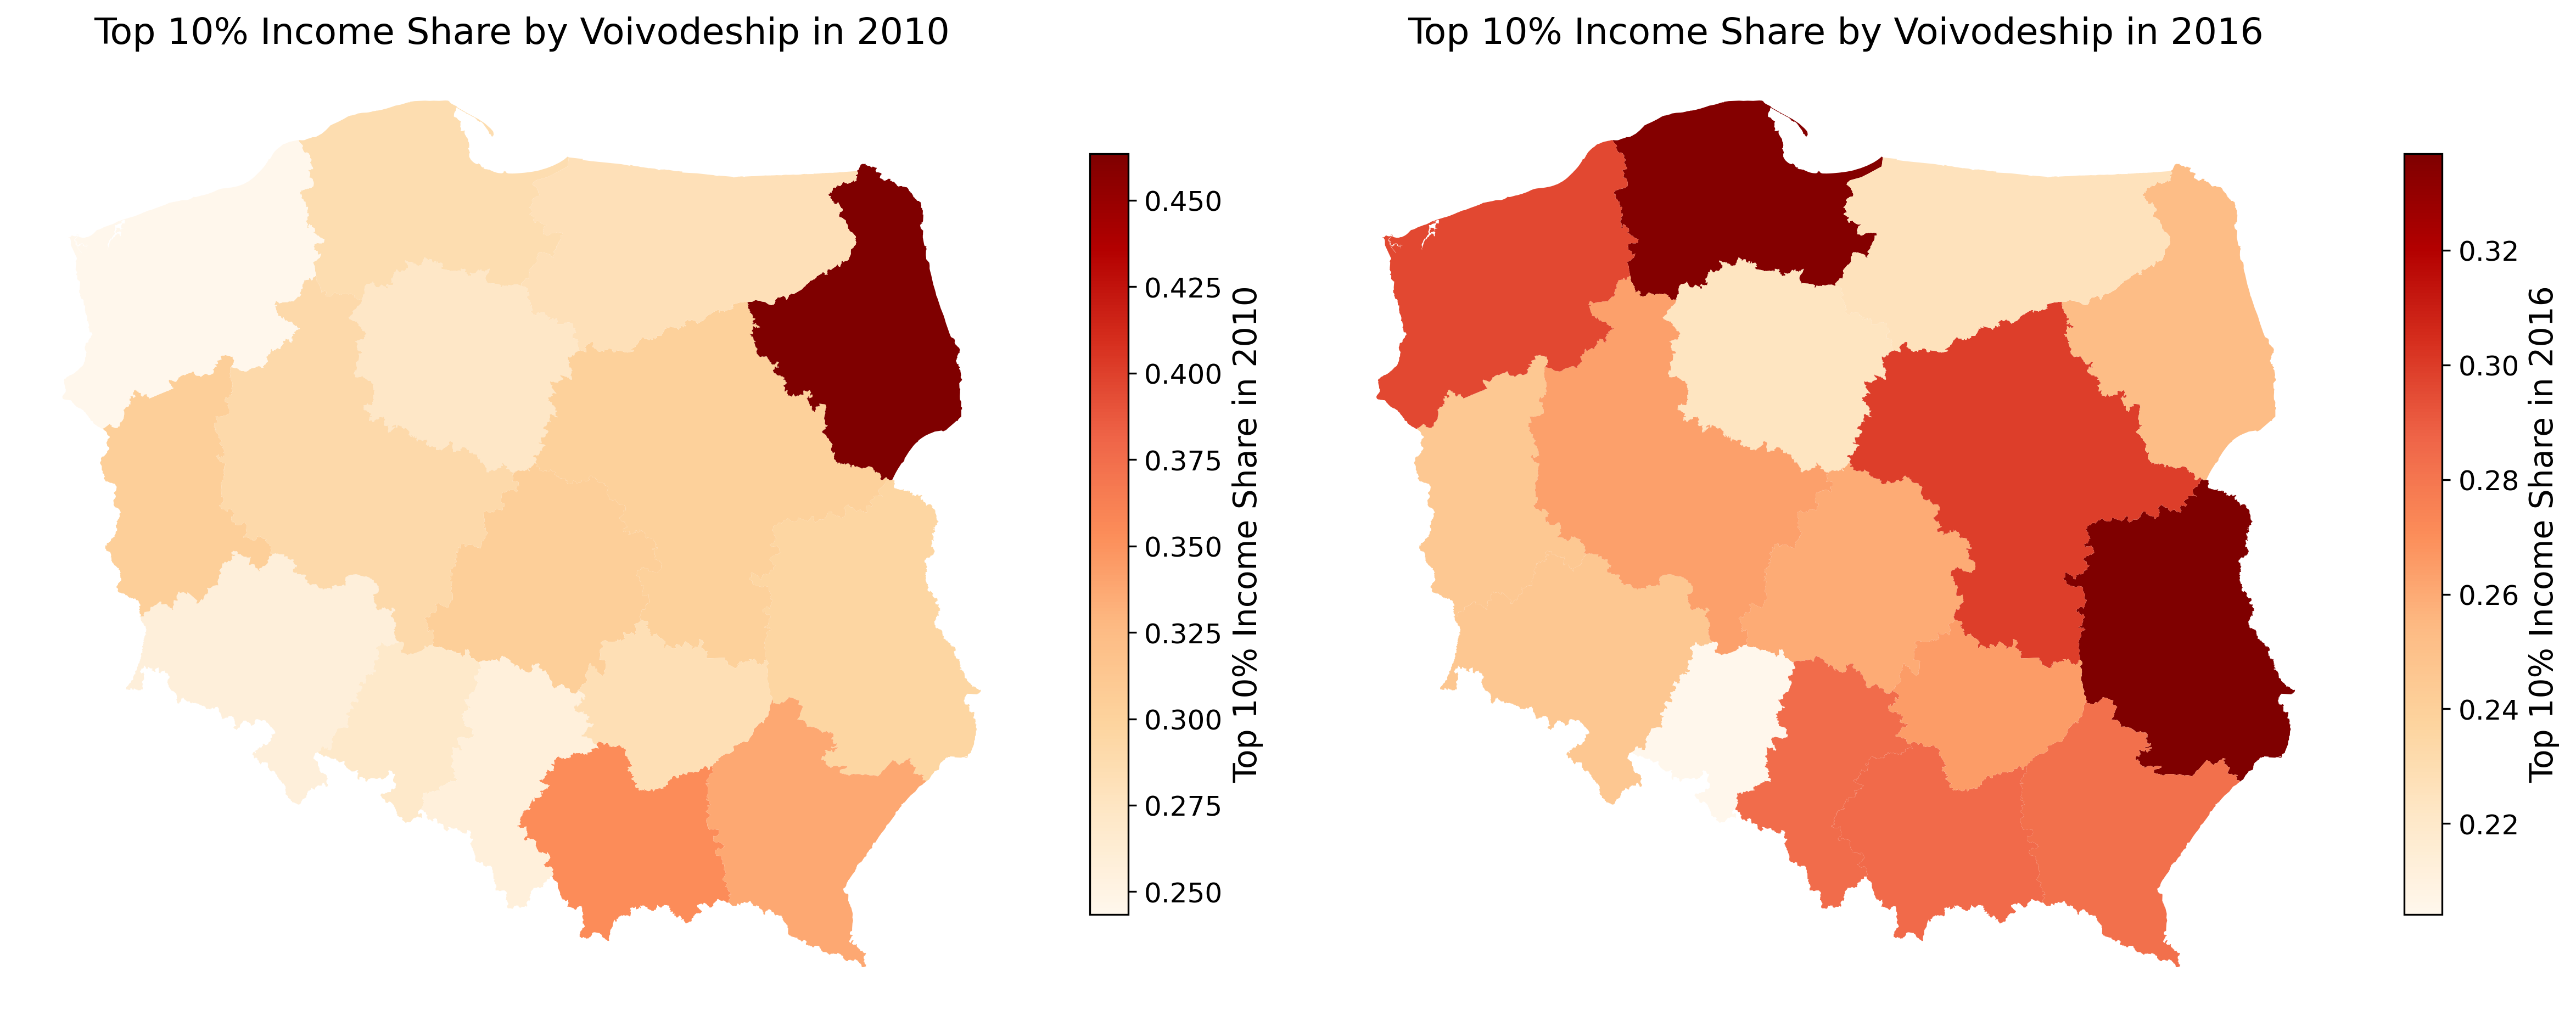

In [54]:
# two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 2000
gdf_shares_2010.plot(column='top_10_share', ax=ax1, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share in 2010",
                                 'shrink': 0.6})
ax1.set_title("Top 10% Income Share by Voivodeship in 2010")
ax1.axis("off")
# Plot for 2016
gdf_shares_2016.plot(column='top_10_share', ax=ax2, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share in 2016",
                                 'shrink': 0.6})
ax2.set_title("Top 10% Income Share by Voivodeship in 2016")
ax2.axis("off")
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_6_Top_10_Income_Share_by_Voivodeship_2010_2016.png', dpi=300)
plt.show()

In [55]:
gdf_shares_2014 = gdf.copy()
for region in regions:
    shares = regions_df[region]['shares']
    shares = shares[shares.index.year == 2014]['top_10'].values[0]
    gdf_shares_2014.loc[gdf_shares_2014['NAME_1'] == region, 'top_10_share'] = shares

gdf_shares_2016 = gdf.copy()
for region in regions:
    shares = regions_df[region]['shares']
    shares = shares[shares.index.year == 2016]['top_10'].values[0]
    gdf_shares_2016.loc[gdf_shares_2016['NAME_1'] == region, 'top_10_share'] = shares

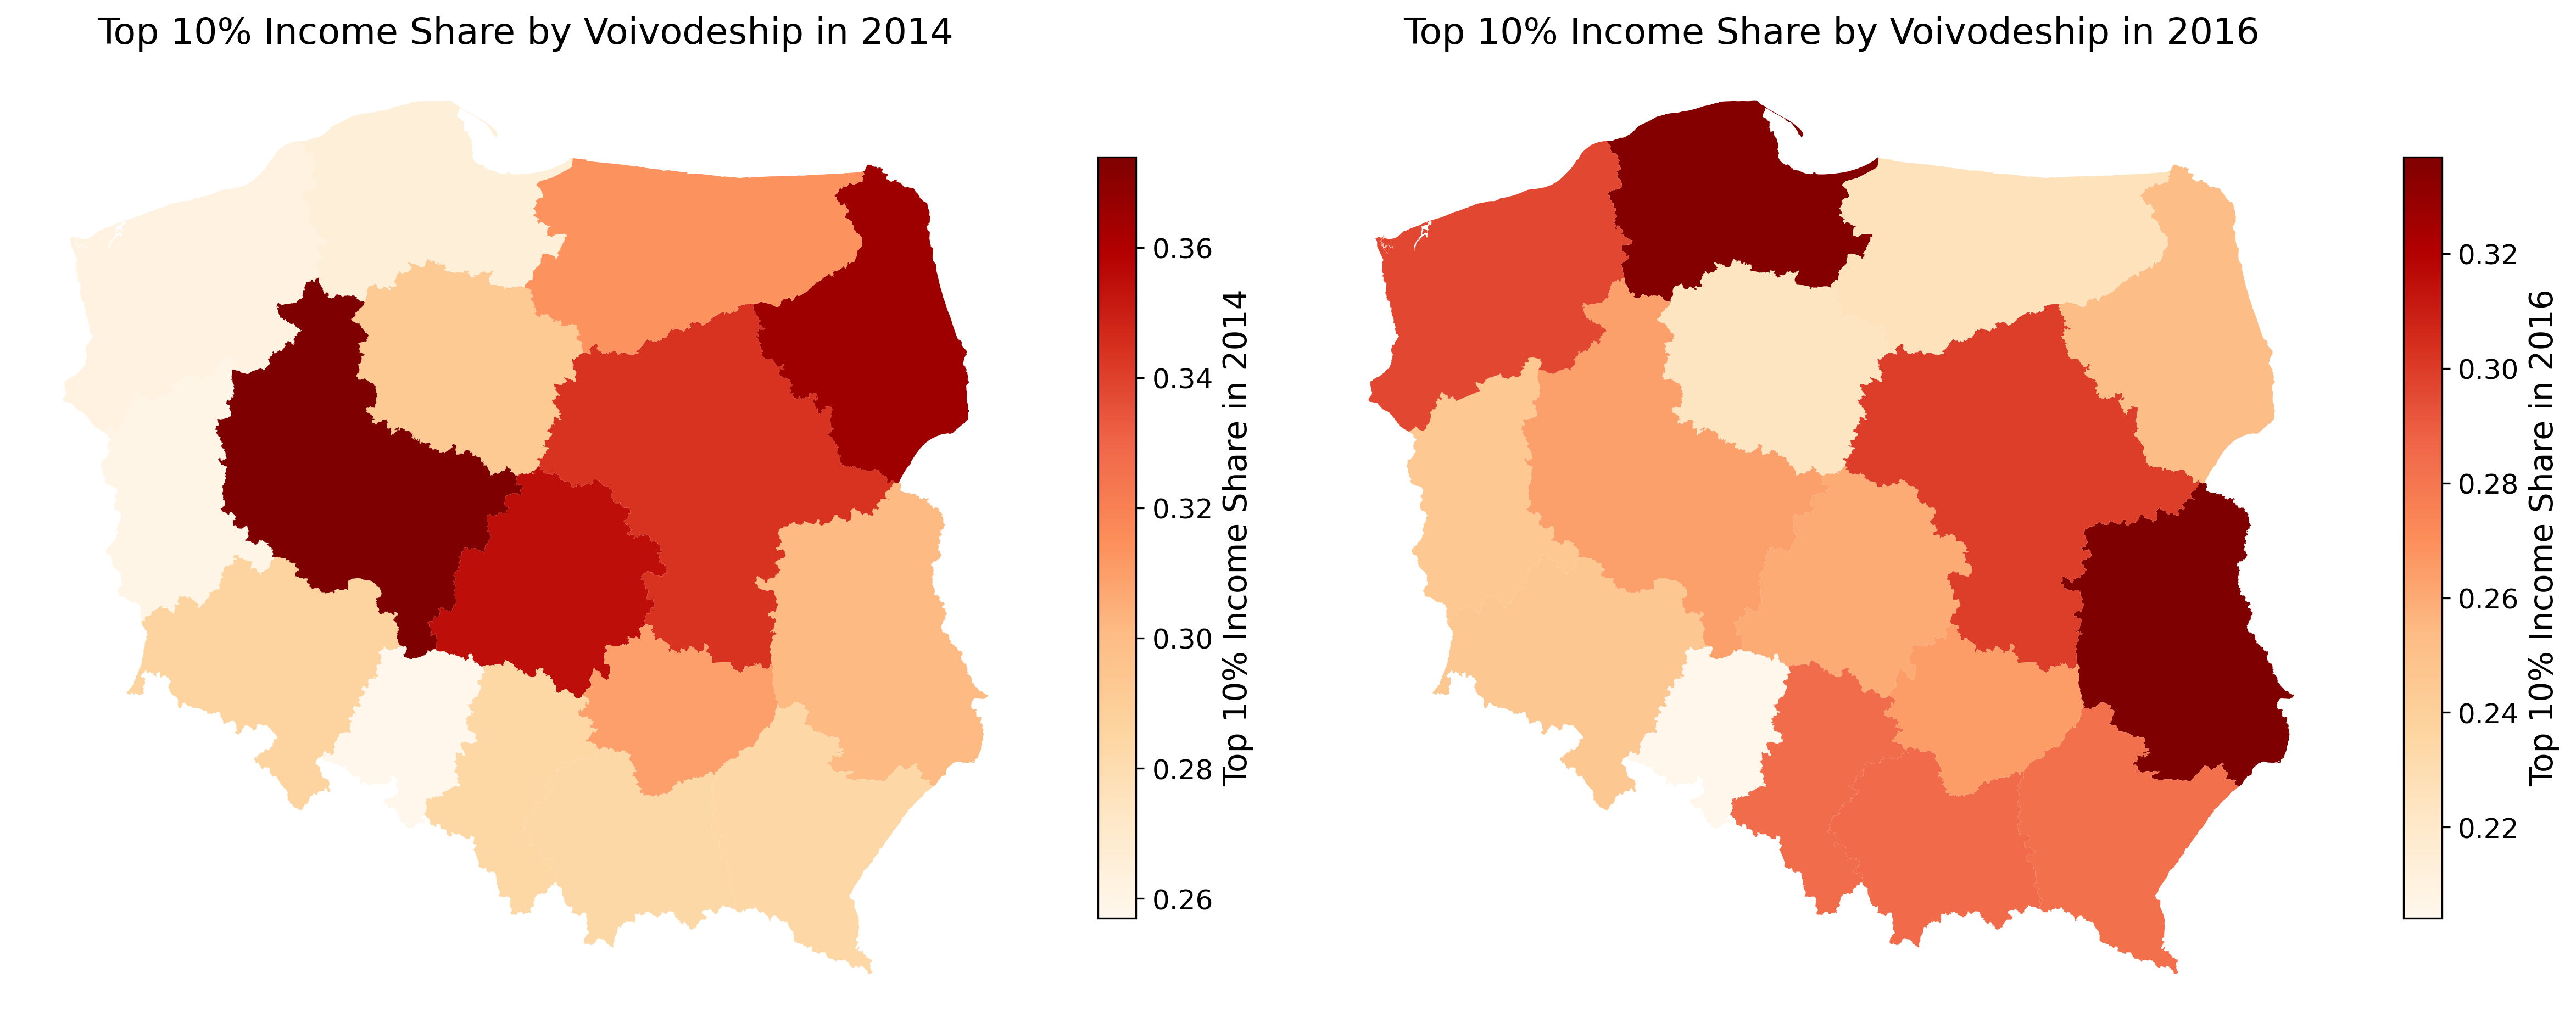

In [56]:
# two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 2000
gdf_shares_2014.plot(column='top_10_share', ax=ax1, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share in 2014",
                                 'shrink': 0.6})
ax1.set_title("Top 10% Income Share by Voivodeship in 2014")
ax1.axis("off")
# Plot for 2016
gdf_shares_2016.plot(column='top_10_share', ax=ax2, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share in 2016",
                                 'shrink': 0.6})
ax2.set_title("Top 10% Income Share by Voivodeship in 2016")
ax2.axis("off")
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_6_Top_10_Income_Share_by_Voivodeship_2014_2016.png', dpi=300)
plt.show()

In [57]:
gdf_shares_2016 = gdf.copy()
for region in regions:
    shares = regions_df[region]['shares']
    shares = shares[shares.index.year == 2016]['top_10'].values[0]
    gdf_shares_2016.loc[gdf_shares_2016['NAME_1'] == region, 'top_10_share'] = shares

gdf_shares_2017 = gdf.copy()
for region in regions:
    shares = regions_df[region]['shares']
    shares = shares[shares.index.year == 2017]['top_10'].values[0]
    gdf_shares_2017.loc[gdf_shares_2017['NAME_1'] == region, 'top_10_share'] = shares

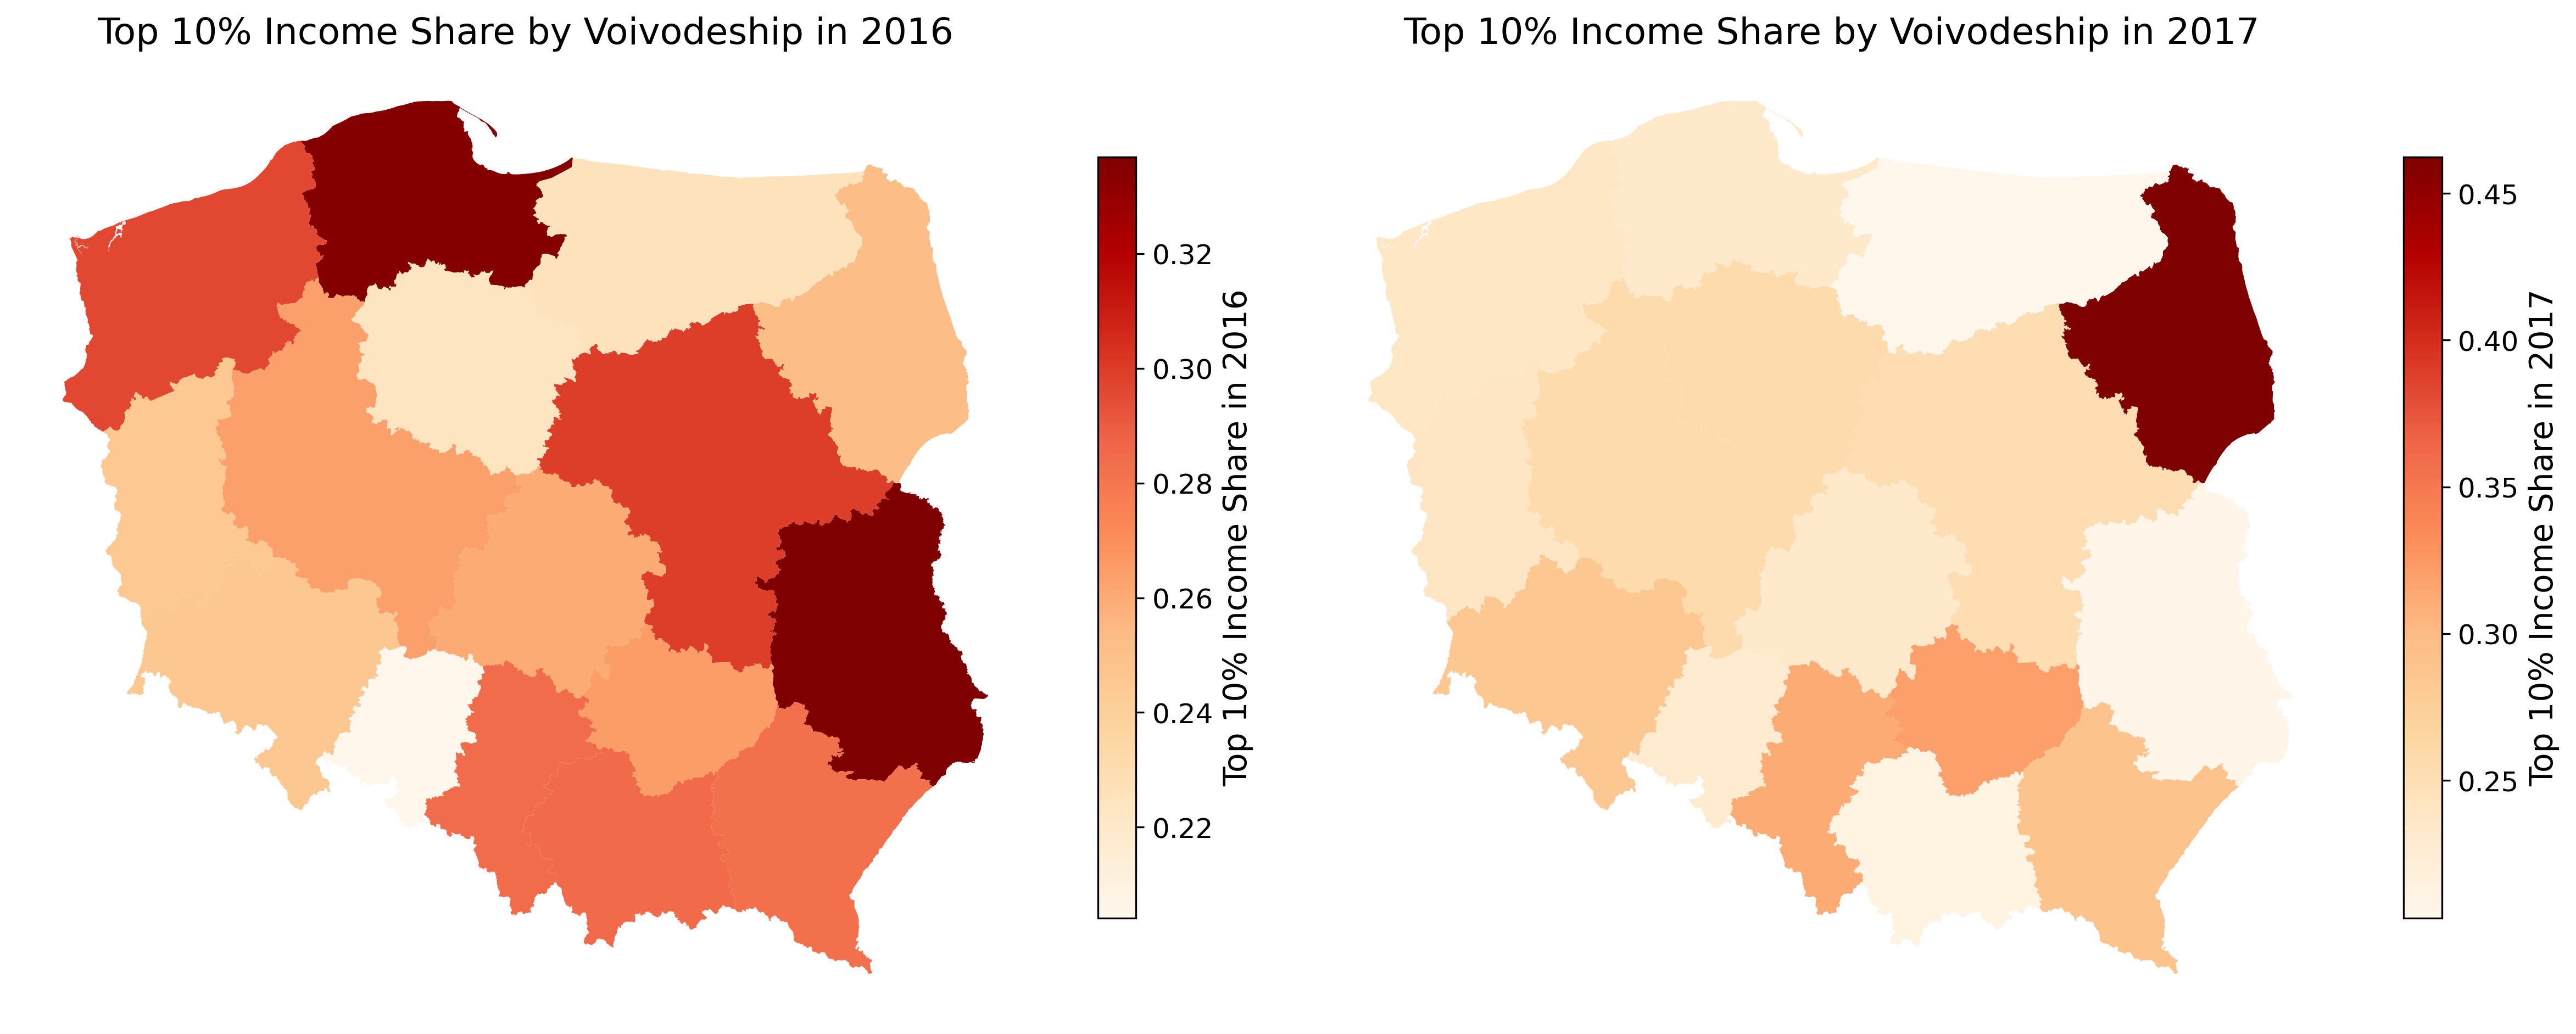

In [58]:
# two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Plot for 2000
gdf_shares_2016.plot(column='top_10_share', ax=ax1, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share in 2016",
                                 'shrink': 0.6})
ax1.set_title("Top 10% Income Share by Voivodeship in 2016")
ax1.axis("off")
# Plot for 2016
gdf_shares_2017.plot(column='top_10_share', ax=ax2, cmap='OrRd', legend=True,
                    legend_kwds={'label': "Top 10% Income Share in 2017",
                                 'shrink': 0.6})
ax2.set_title("Top 10% Income Share by Voivodeship in 2017")
ax2.axis("off")
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_6_Top_10_Income_Share_by_Voivodeship_2016_2017.png', dpi=300)
plt.show()

# Theil Index Decomposition

The Theil T index measures inequality and can be decomposed into:
- **Between-region component**: Inequality due to differences in mean income across regions
- **Within-region component**: Inequality within each region, weighted by income share

Formula: Total Theil = Between + Within

In [59]:
# Compute Theil decomposition for selected years
# Create analyzer for the full dataset with regional information
IA_full = inqA.InequalityAnalyzer(df_new_regions, income_col='income_hh_deflated', annual_frequency=True)

# Compute Theil decomposition for several years
years_to_analyze = [1999, 2000, 2010, 2014, 2016, 2017]
theil_results = {}

for year in years_to_analyze:
    result = IA_full.compute_theil_decomposition(
        year=year,
        regions=regions,
        region_col='location_new_L',
        use_total_income=True
    )
    theil_results[year] = result
    
    print(f"\n{'='*60}")
    print(f"Year {year}")
    print(f"{'='*60}")
    print(f"Total Theil Index:        {result['total_theil']:.4f}")
    print(f"Between-region component: {result['between_component']:.4f} ({result['between_component']/result['total_theil']*100:.1f}%)")
    print(f"Within-region component:  {result['within_component']:.4f} ({result['within_component']/result['total_theil']*100:.1f}%)")
    print(f"Overall mean income:      {result['overall_mean']:.2f} PLN")
    
# Create a summary DataFrame
theil_summary = pd.DataFrame({
    'year': years_to_analyze,
    'total_theil': [theil_results[y]['total_theil'] for y in years_to_analyze],
    'between': [theil_results[y]['between_component'] for y in years_to_analyze],
    'within': [theil_results[y]['within_component'] for y in years_to_analyze]
})
theil_summary['between_pct'] = theil_summary['between'] / theil_summary['total_theil'] * 100
theil_summary['within_pct'] = theil_summary['within'] / theil_summary['total_theil'] * 100

print("\n" + "="*60)
print("Summary Table")
print("="*60)
print(theil_summary.to_string(index=False))
# Change year to datetime
theil_summary['year'] = pd.to_datetime(theil_summary['year'], format='%Y')


Year 1999
Total Theil Index:        0.2239
Between-region component: 0.0064 (2.9%)
Within-region component:  0.2174 (97.1%)
Overall mean income:      116.76 PLN

Year 2000
Total Theil Index:        0.2152
Between-region component: 0.0060 (2.8%)
Within-region component:  0.2093 (97.2%)
Overall mean income:      108.81 PLN

Year 2010
Total Theil Index:        0.2780
Between-region component: 0.0034 (1.2%)
Within-region component:  0.2746 (98.8%)
Overall mean income:      137.72 PLN

Year 2014
Total Theil Index:        0.2879
Between-region component: 0.0045 (1.6%)
Within-region component:  0.2834 (98.4%)
Overall mean income:      152.15 PLN

Year 2016
Total Theil Index:        0.2638
Between-region component: 0.0071 (2.7%)
Within-region component:  0.2567 (97.3%)
Overall mean income:      172.33 PLN

Year 2017
Total Theil Index:        0.2225
Between-region component: 0.0117 (5.3%)
Within-region component:  0.2107 (94.7%)
Overall mean income:      185.44 PLN

Summary Table
 year  total_

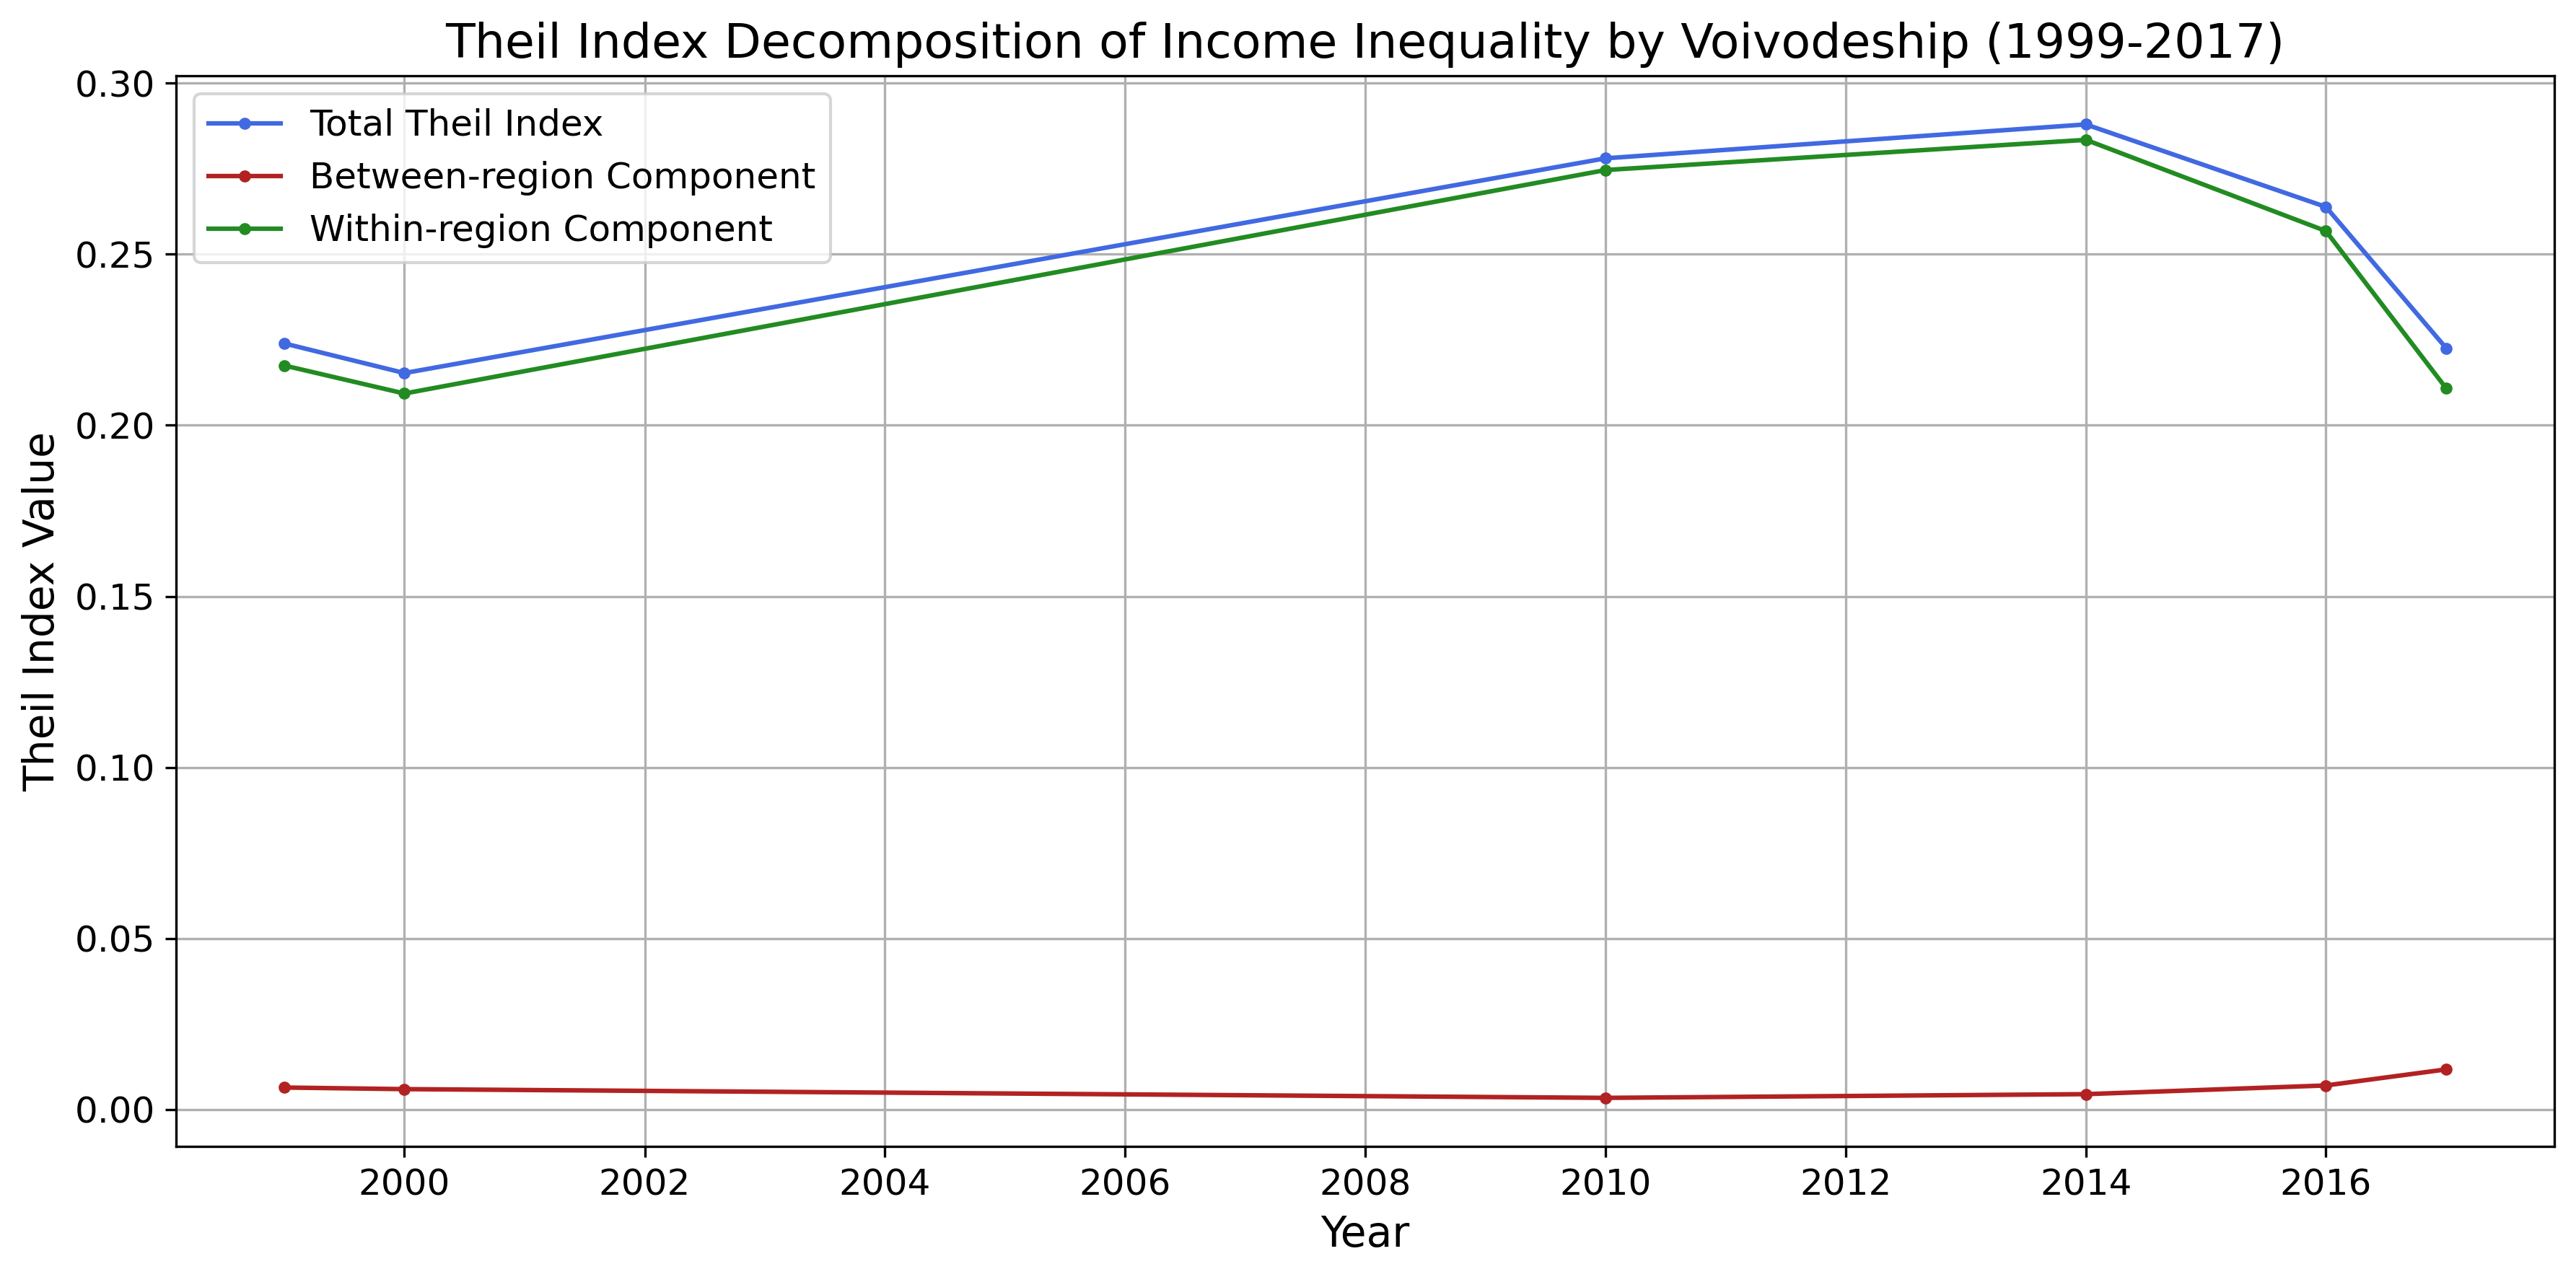

In [65]:
# Plot Theil index components over time
plt.figure(figsize=(12, 6))
plt.plot(theil_summary['year'], theil_summary['total_theil'], marker='.', label='Total Theil Index', color='royalblue')
plt.plot(theil_summary['year'], theil_summary['between'], marker='.', label='Between-region Component', color='firebrick')
plt.plot(theil_summary['year'], theil_summary['within'], marker='.', label='Within-region Component', color='forestgreen')
plt.title('Theil Index Decomposition of Income Inequality by Voivodeship (1999-2017)')
plt.xlabel('Year')
plt.ylabel('Theil Index Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_7_Theil_Index_Decomposition_by_Voivodeship_1999_2017.png', dpi=300)
plt.show()



In [61]:
# Create geodataframes for regional Theil indices
# We'll map the within-region Theil index for each voivodeship

# Function to create GeoDataFrame with regional Theil values
def create_theil_gdf(year):
    gdf_theil = gdf.copy()
    result = theil_results[year]
    for region in regions:
        theil_value = result['region_theils'].get(region, np.nan)
        gdf_theil.loc[gdf_theil['NAME_1'] == region, 'theil_within'] = theil_value
    return gdf_theil

# Create geodataframes for selected years
gdf_theil_1999 = create_theil_gdf(1999)
gdf_theil_2000 = create_theil_gdf(2000)
gdf_theil_2010 = create_theil_gdf(2010)
gdf_theil_2016 = create_theil_gdf(2016)

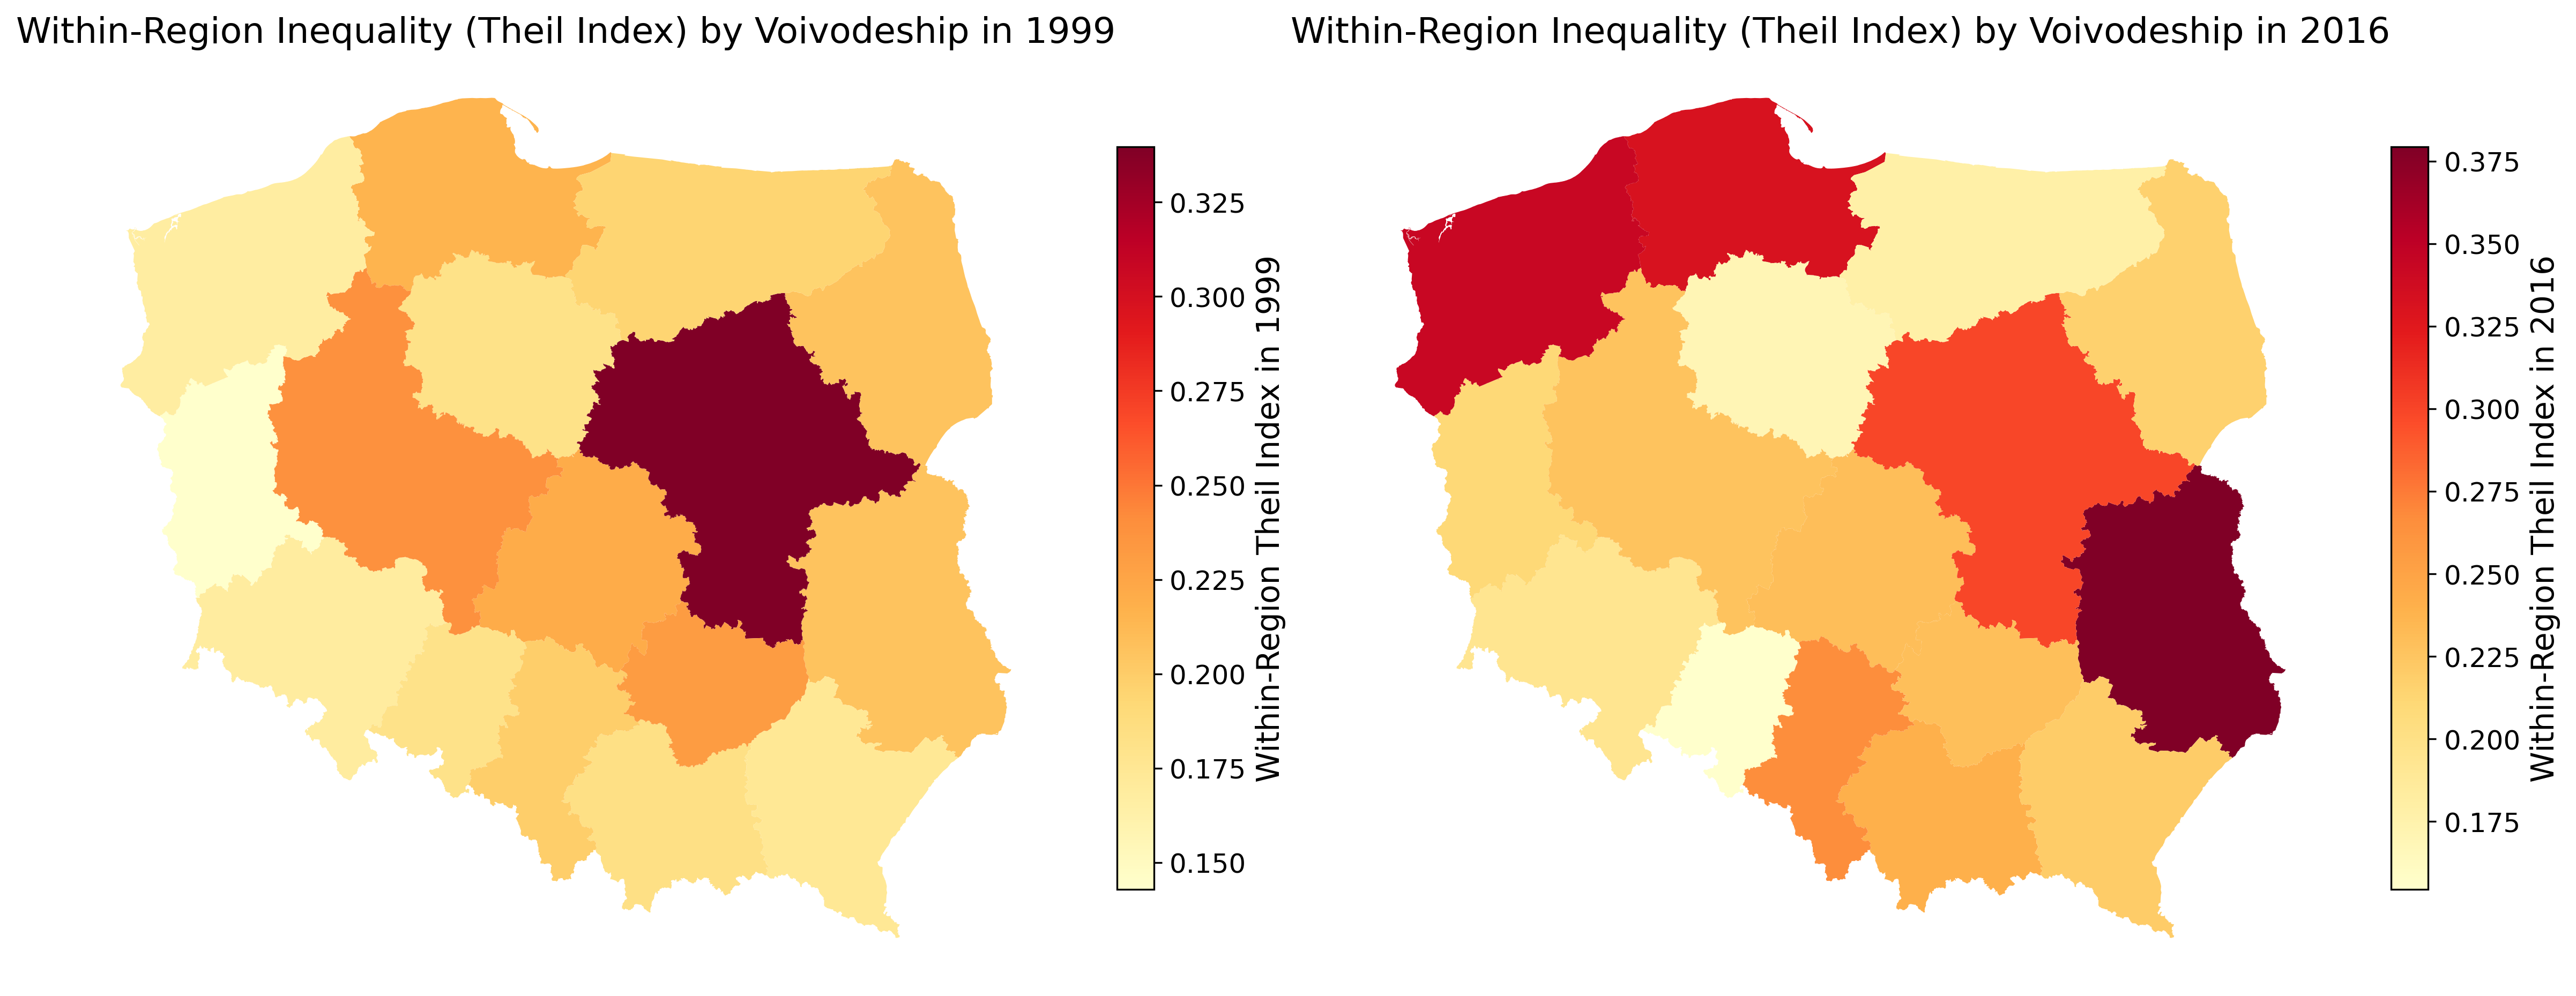

In [62]:
# Map within-region Theil index for 1999 and 2016
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot for 1999
gdf_theil_1999.plot(column='theil_within', ax=ax1, cmap='YlOrRd', legend=True,
                    legend_kwds={'label': "Within-Region Theil Index in 1999",
                                 'shrink': 0.6})
ax1.set_title("Within-Region Inequality (Theil Index) by Voivodeship in 1999")
ax1.axis("off")

# Plot for 2016
gdf_theil_2016.plot(column='theil_within', ax=ax2, cmap='YlOrRd', legend=True,
                    legend_kwds={'label': "Within-Region Theil Index in 2016",
                                 'shrink': 0.6})
ax2.set_title("Within-Region Inequality (Theil Index) by Voivodeship in 2016")
ax2.axis("off")

plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_8_Theil_Within_Region_1999_2016.png', dpi=300)
plt.show()

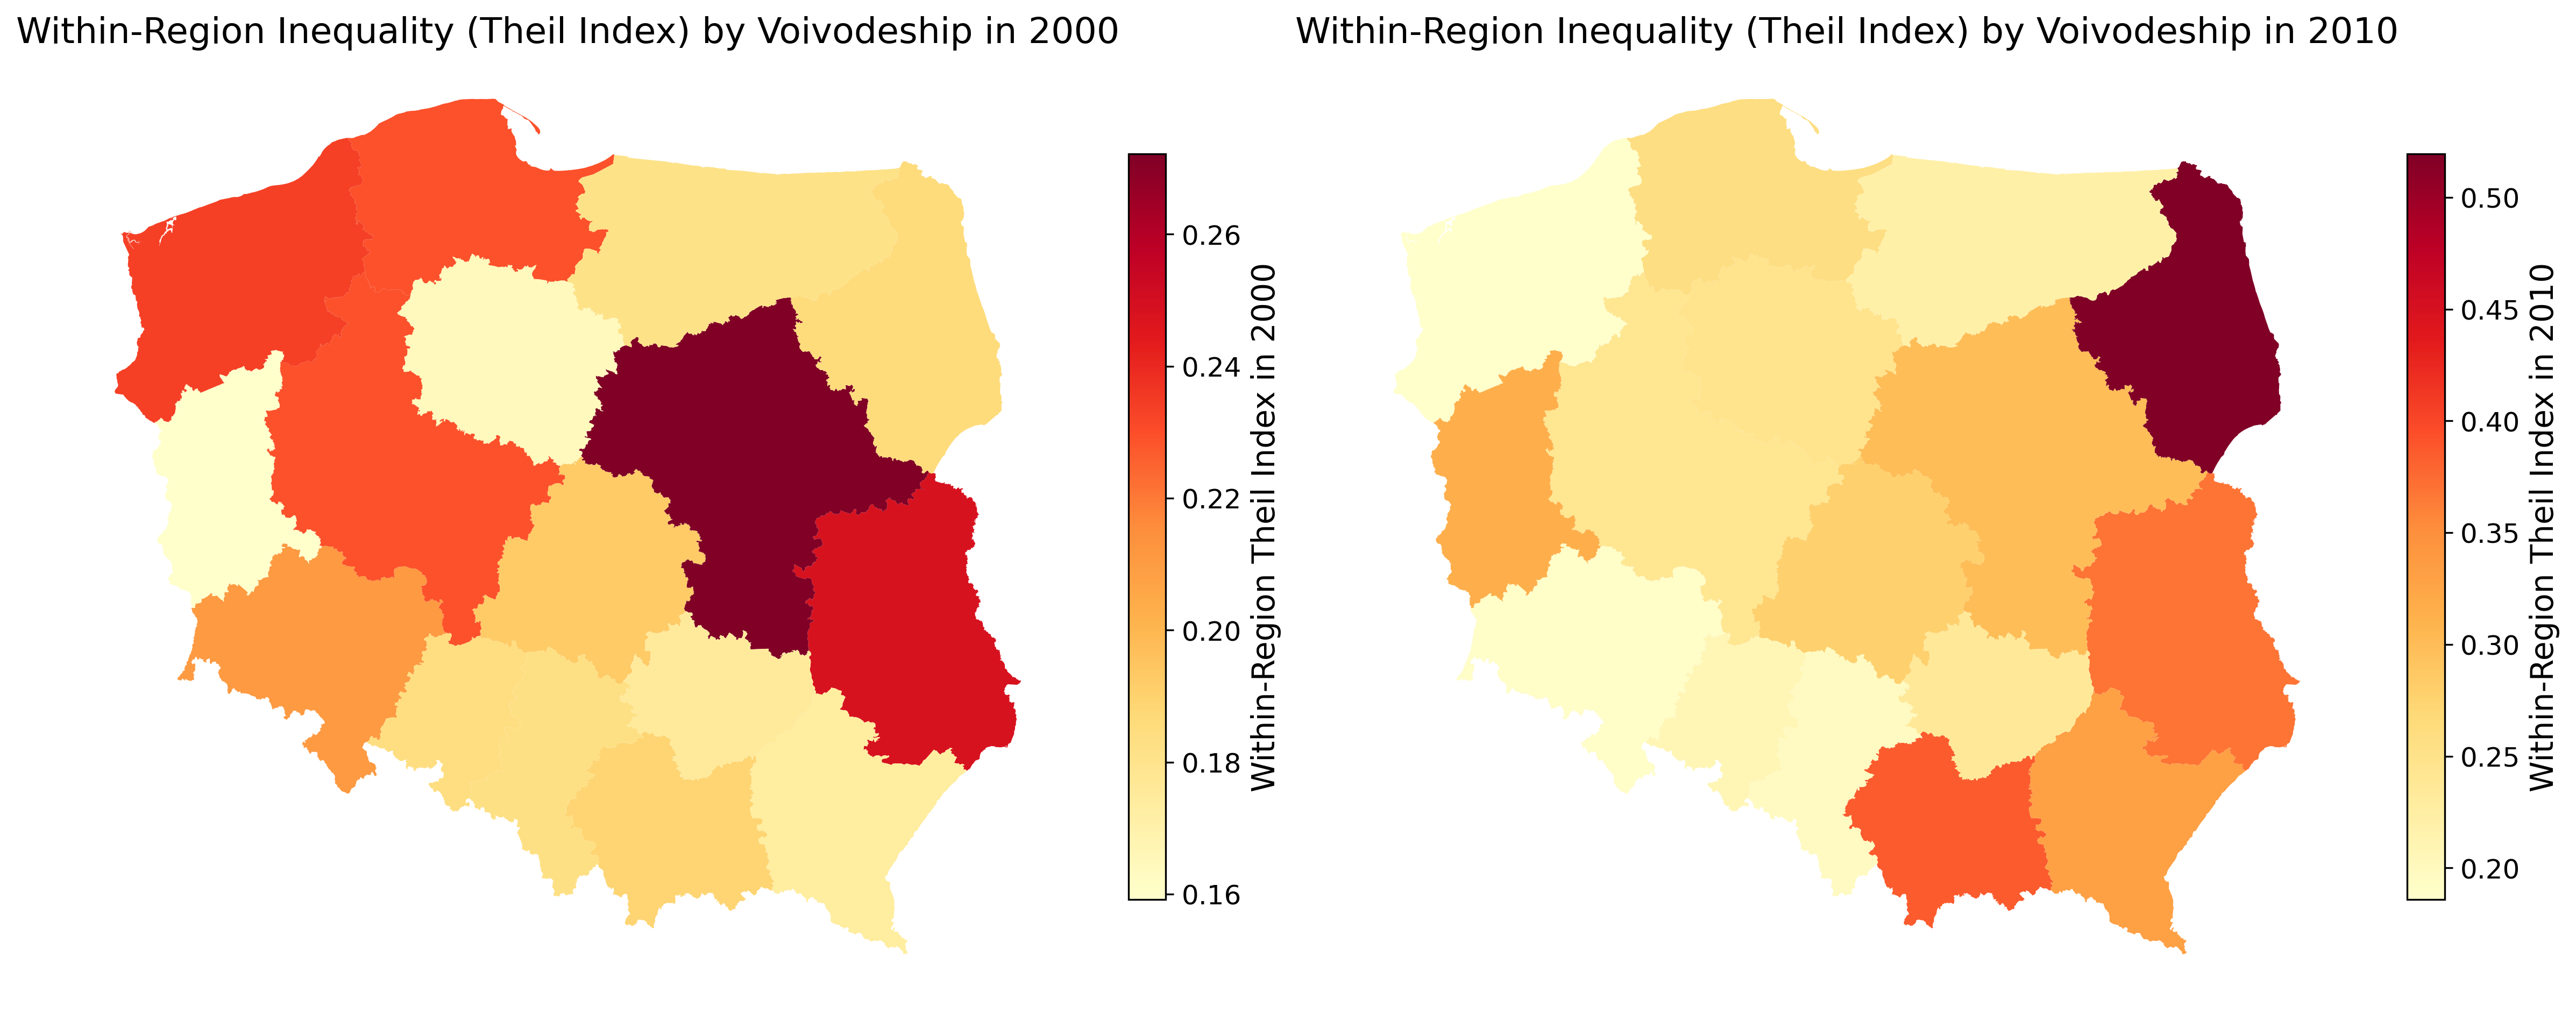

In [63]:
# Map within-region Theil index for 2000 and 2010
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot for 2000
gdf_theil_2000.plot(column='theil_within', ax=ax1, cmap='YlOrRd', legend=True,
                    legend_kwds={'label': "Within-Region Theil Index in 2000",
                                 'shrink': 0.6})
ax1.set_title("Within-Region Inequality (Theil Index) by Voivodeship in 2000")
ax1.axis("off")

# Plot for 2010
gdf_theil_2010.plot(column='theil_within', ax=ax2, cmap='YlOrRd', legend=True,
                    legend_kwds={'label': "Within-Region Theil Index in 2010",
                                 'shrink': 0.6})
ax2.set_title("Within-Region Inequality (Theil Index) by Voivodeship in 2010")
ax2.axis("off")

plt.tight_layout()
plt.savefig(plot_root / 'CBOS_05_9_Theil_Within_Region_2000_2010.png', dpi=300)
plt.show()

In [64]:
# Display regional details for 2016
print("="*80)
print("Regional Theil Decomposition Details for 2016")
print("="*80)
result_2016 = theil_results[2016]

# Create a DataFrame for better visualization
regional_details = pd.DataFrame({
    'Region': regions,
    'Mean Income': [result_2016['region_means'][r] for r in regions],
    'Income Share': [result_2016['region_shares'][r] * 100 for r in regions],
    'Within Theil': [result_2016['region_theils'][r] for r in regions]
})

regional_details = regional_details.sort_values('Within Theil', ascending=False)
print(regional_details.to_string(index=False))

print(f"\nOverall mean income: {result_2016['overall_mean']:.2f} PLN")
print(f"\nBetween-region component: {result_2016['between_component']:.4f}")
print(f"Within-region component: {result_2016['within_component']:.4f}")
print(f"Total Theil index: {result_2016['total_theil']:.4f}")

Regional Theil Decomposition Details for 2016
             Region  Mean Income  Income Share  Within Theil
          Lubelskie   168.841997      6.658623      0.379384
 Zachodniopomorskie   160.113365      5.292504      0.342728
          Pomorskie   210.036695      7.551116      0.331877
        Mazowieckie   194.442126     13.860016      0.298892
            Śląskie   187.250824     13.329435      0.266254
        Małopolskie   170.428522      6.291665      0.240165
            Łódzkie   129.840640      3.300099      0.230527
     Świętokrzyskie   163.598815      3.109037      0.229778
      Wielkopolskie   178.764646      7.250419      0.227076
       Podkarpackie   172.214095      6.862516      0.219980
          Podlaskie   171.303000      3.163329      0.216778
           Lubuskie   167.893673      2.906193      0.210563
       Dolnośląskie   175.517548      9.769665      0.193255
Warmińsko-mazurskie   138.606894      4.210850      0.178935
 Kujawsko-pomorskie   138.572994      3